<a href="https://colab.research.google.com/github/marco-siino/Agentic-ORAN-LLM/blob/main/Mistral_DDoSSimulation_Weights_A_LLM%2BDRL_Updated_08_07_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario 3 (Semantic Security Override)

# Installazione librerie

In [1]:
!pip install mistralai gymnasium stable-baselines3 shimmy pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.2/76.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 2.5 MB/s eta 0:00:00
  Attempting uninstall: importlib-metadata
    Found existing installation: importlib_metadata 9.0.0
    Uninstalling importlib_metadata-9.0.0:
      Successfully uninstalled importlib_metadata-9.0.0
  Attempting uninstall: opentelemetry-api
    Found existing installation: opentelemetry-api 1.42.1
    Uninstalling opentelemetry-api-1.42.1:
      Successfully uninstalled opentelemetry-api-1.42.1
  Attempting uninstall: opentelemetry-semantic-conventions
    Found existing installation: opentelemetry-semantic-conventions 0.63b1
    Uninstalling opentelemetry-semantic-conventions-0.63b1:
      Succes

# Esperimenti finali Paper

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import requests


# ==============================================================================
# 1. CONFIGURAZIONE
# ==============================================================================
# ⚠️ ATTENZIONE: Questa chiave è esposta. Ti consiglio di revocarla e generarne una nuova.
API_KEY = '7yOu0lH5XcZC1U2ZUI2uv0ghBDduhHp5'
MODEL_NAME = "mistral-small-latest"

USE_MOCK_LLM = False

# ==============================================================================
# 2. LOGICA MISTRAL (API Diretta con Exponential Backoff)
# ==============================================================================
def get_llm_weights_per_cell(step, cell_id, price, traffic, safety_val, external_context):
    prompt_txt = f"""
    Context (Step {step}, Cell {cell_id}):
    - Energy Price: {price:.2f}x
    - Traffic: {traffic:.0f}%
    - External Context: {external_context}

    Task: Output JSON weights (w_thr, w_eng, w_safe) summing to 1.0.
    Logic:
    1. SECURITY QUARANTINE: If DDoS is detected -> (w_eng = 1.0, w_thr = 0.0, w_safe = 0.0).
    2. Emergency (>80): w_safe = 1.0.
    3. Normal: Balance w_thr and w_eng.

    Output JSON ONLY: {{"w_thr": float, "w_eng": float, "w_safe": float}}
    """

    url = "https://api.mistral.ai/v1/chat/completions"
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {API_KEY}"
    }
    data = {
        "model": MODEL_NAME,
        "messages": [{"role": "user", "content": prompt_txt}],
        "temperature": 0.1 # Temperatura bassa per JSON più stabili
    }

    max_retries = 5 # Numero massimo di tentativi in caso di Rate Limit

    for attempt in range(max_retries):
        try:
            response = requests.post(url, headers=headers, json=data)

            # Se la chiamata va a buon fine
            if response.status_code == 200:
                result = response.json()
                content = result["choices"][0]["message"]["content"]
                clean_json = content.replace("```json", "").replace("```", "").strip()
                d = json.loads(clean_json)
                return float(d.get('w_thr', 0.3)), float(d.get('w_eng', 0.3)), float(d.get('w_safe', 0.0)), prompt_txt, clean_json

            # Se colpiamo il Rate Limit (429 Too Many Requests)
            elif response.status_code == 429:
                wait_time = 2 ** attempt # Pausa esponenziale: 1s, 2s, 4s, 8s, 16s
                print(f"\n[⚠️ API Limit] Rate limit raggiunto allo step {step}. Attesa di {wait_time}s (Tentativo {attempt+1}/{max_retries})...")
                time.sleep(wait_time)
                continue

            # Per altri errori HTTP (es. 401 Unauthorized, 500 Server Error)
            else:
                print(f"\n[❌ API Error] Step {step}, Cell {cell_id}: HTTP {response.status_code} - {response.text}")
                break # Interrompiamo i tentativi per errori fatali

        except Exception as e:
            print(f"\n[❌ Network Exception] Step {step}, Cell {cell_id}: {e}")
            time.sleep(2) # Pausa fissa prima di riprovare in caso di disconnessione

    # Fallback in caso di fallimento totale
    print(f"\n[!] Fallback attivato per Step {step}, Cell {cell_id}")
    return 0.7, 0.3, 0.0, prompt_txt, '{"error": "failed_after_retries"}'

# ==============================================================================
# 3. AMBIENTE GYM O-RAN (Physics Engine)
# ==============================================================================
class ORAN3CellsEnv(gym.Env):
    def __init__(self):
        super(ORAN3CellsEnv, self).__init__()
        self.n_cells = 3
        self.action_space = spaces.Box(low=5.0, high=60.0, shape=(3,), dtype=np.float32)
        self.observation_space = spaces.Box(low=0, high=100, shape=(10,), dtype=np.float32)

        self.bandwidth = 100.0 # MHz
        self.noise = 1.0       # Noise floor normalizzato
        self.max_pwr = 60.0
        self.min_pwr = 5.0

    def _calculate_metrics(self, power, traffic, price):
        snr = power / self.noise
        capacity = self.bandwidth * np.log2(1 + snr)
        throughput = capacity * (traffic / 100.0)

        consumption = power
        cost = power * price

        risk = ((self.max_pwr - power) / (self.max_pwr - self.min_pwr))**2
        return throughput, consumption, cost, risk

    def step(self, actions, context):
        price = context['price']
        traffic_arr = context['traffic']

        metrics = []
        for i in range(self.n_cells):
            t, cons, c, r = self._calculate_metrics(actions[i], traffic_arr[i], price)
            metrics.append({'thr': t, 'cons': cons, 'cost': c, 'risk': r})

        return np.zeros(10), metrics, False, False, {}

# ==============================================================================
# 4. AGENTE OTTIMIZZATORE (DRL Solver)
# ==============================================================================
def optimize_power(w_thr, w_eng, w_safe, price, traffic, env_instance):
    best_p = 5.0
    best_score = -np.inf

    for p in np.linspace(5, 60, 50):
        t, cons, c, r = env_instance._calculate_metrics(p, traffic, price)

        n_t = t / 800.0
        n_c = c / 600.0
        n_r = r

        score = (w_thr * n_t) - (w_eng * n_c) - (w_safe * n_r)

        if score > best_score:
            best_score = score
            best_p = p

    return best_p

# ==============================================================================
# 5. ESECUZIONE SIMULAZIONE (AGGIORNATA A 50 STEP)
# ==============================================================================
def run_experiment():
    env = ORAN3CellsEnv()
    steps = 50  # <-- MODIFICATO DA 40 A 50 PER INCLUDERE L'EVENTO
    history = []

    # --- GENERAZIONE SCENARI ---
    prices = np.ones(steps)
    prices[15] = 8.0
    for t in range(16, 30):
        prices[t] = 1.0 + 7.0 * np.exp(-0.3 * (t-15))

    traffic_c = []
    np.random.seed(42)
    base_trend = np.linspace(40, 70, steps)
    for i in range(3):
        noise = np.random.normal(0, 5, steps)
        tr = base_trend + noise
        tr = np.clip(tr, 10, 100)
        traffic_c.append(tr)

    safety_c2 = np.zeros(steps)
    safety_c2[25] = 50.0
    safety_c2[26:28] = 100.0
    safety_c2[28] = 50.0

    print("🚀 AVVIO SIMULAZIONE GYM + MISTRAL API...")

    for t in range(steps):
        p = prices[t]
        row_data = {'Step': t, 'Price': p}

        for i in range(3):
            cid = i + 1
            tr = traffic_c[i][t]
            safe = safety_c2[t] if cid == 2 else 0.0

            # <-- PROMPT GENERICO INVECE DI DDOS
            external_context = "CRITICAL LOG: Extreme inexplicable anomaly and resource saturation detected" if (t >= 40 and cid == 3) else "None"

            # --- 1. A-LLM (Agentic) ---
            print(f"\rStep {t}/{steps-1} - Cell {cid}: Calling Mistral...", end="", flush=True)

            wa_t, wa_e, wa_s, _, _ = get_llm_weights_per_cell(t, cid, p, tr, safe, external_context)

            # PAUSA DI BASE
            time.sleep(1.2)

            p_agentic = optimize_power(wa_t, wa_e, wa_s, p, tr, env)

            # --- 2. DRL (Baseline) ---
            wb_t, wb_e, wb_s = 0.8, 0.2, 0.0
            p_baseline = optimize_power(wb_t, wb_e, wb_s, p, tr, env)

            # --- 3. GYM STEP ---
            ta, cons_a, ca, ra = env._calculate_metrics(p_agentic, tr, p)
            tb, cons_b, cb, rb = env._calculate_metrics(p_baseline, tr, p)

            # Save Data
            prefix = f"C{cid}"
            row_data[f'{prefix}_Traffic'] = tr
            row_data[f'{prefix}_Safety'] = safe

            row_data[f'{prefix}_Cons_A'] = cons_a
            row_data[f'{prefix}_Cons_B'] = cons_b

            row_data[f'{prefix}_Thr_A'] = ta
            row_data[f'{prefix}_Thr_B'] = tb

            row_data[f'{prefix}_Risk_A'] = ra
            row_data[f'{prefix}_Risk_B'] = rb

            # <-- SALVIAMO I PESI PER IL NUOVO GRAFICO AD AREA
            row_data[f'{prefix}_w_thr'] = wa_t
            row_data[f'{prefix}_w_eng'] = wa_e
            row_data[f'{prefix}_w_safe'] = wa_s

        history.append(row_data)

    print("\n✅ Simulazione Completata.")
    return pd.DataFrame(history)

# ==============================================================================
# 6. PLOTTING AGGIORNATO
# ==============================================================================
def plot_results(df):
    fig, axes = plt.subplots(3, 3, figsize=(20, 12))
    plt.subplots_adjust(hspace=0.4, wspace=0.35)

    cols = ["Consumo Energetico\n(vs Prezzo)", "Throughput Reale\n(vs Traffico)", "Rischio Sicurezza\n(vs Emergenza)"]
    for ax, t in zip(axes[0], cols): ax.set_title(t, fontweight='bold', pad=15)

    for i in range(3):
        cid = i + 1
        pid = f"C{cid}"

        axes[i, 0].text(-0.25, 0.5, f"CELLA {cid}", transform=axes[i, 0].transAxes,
                        rotation=90, fontweight='bold', fontsize=12, va='center')

        # --- GRAFICO 1 ---
        ax = axes[i, 0]
        l1, = ax.plot(df['Step'], df[f'{pid}_Cons_B'], 'r-', label='DRL (Baseline)')
        l2, = ax.plot(df['Step'], df[f'{pid}_Cons_A'], 'b-', label='A-LLM (Agentic)')
        ax.set_ylim(0, 70)
        ax.set_ylabel("Consumo (W)", fontweight='bold')
        if i==2: ax.set_xlabel("Time Step")

        ax2 = ax.twinx()
        l3, = ax2.plot(df['Step'], df['Price'], 'k--', alpha=0.6, label='Prezzo Energia')
        ax2.fill_between(df['Step'], 0, df['Price'], color='gray', alpha=0.1)
        ax2.set_ylabel("Prezzo ($/kWh)", color='gray')

        if i==0: ax.legend([l1, l2, l3], ['Consumo DRL', 'Consumo A-LLM', 'Prezzo'], loc='upper left', fontsize=8)

        # --- GRAFICO 2 ---
        ax = axes[i, 1]
        l1, = ax.plot(df['Step'], df[f'{pid}_Thr_B'], 'r-')
        l2, = ax.plot(df['Step'], df[f'{pid}_Thr_A'], 'b-')
        ax.set_ylabel("Throughput (Mbps)", fontweight='bold')
        if i==2: ax.set_xlabel("Time Step")

        ax2 = ax.twinx()
        l3, = ax2.plot(df['Step'], df[f'{pid}_Traffic'], 'k--', alpha=0.6)
        ax2.set_ylabel("Utenti (%)", color='gray')
        ax2.set_ylim(0, 110)

        if i==0: ax.legend([l1, l2, l3], ['Thr DRL', 'Thr A-LLM', 'Traffico'], loc='lower right', fontsize=8)

        # --- GRAFICO 3 ---
        ax = axes[i, 2]
        l1, = ax.plot(df['Step'], df[f'{pid}_Risk_B'], 'r-')
        l2, = ax.plot(df['Step'], df[f'{pid}_Risk_A'], 'b-')
        ax.set_ylim(-0.1, 1.1)
        ax.set_ylabel("Rischio (0-1)", fontweight='bold')
        if i==2: ax.set_xlabel("Time Step")

        ax2 = ax.twinx()
        safe_data = df[f'{pid}_Safety']
        l3, = ax2.plot(df['Step'], safe_data, 'k--', alpha=0.6)
        if safe_data.max() > 0:
            ax2.fill_between(df['Step'], 0, safe_data, color='orange', alpha=0.2)
        ax2.set_ylabel("Emergenza (0-100)", color='gray')
        ax2.set_ylim(0, 110)

        if i==0: ax.legend([l1, l2, l3], ['Rischio DRL', 'Rischio A-LLM', 'Emergenza'], loc='upper left', fontsize=8)

    plt.suptitle("SCENARIO 1: Impatto Dinamico (Gym + Mistral API Reale)", fontsize=16, y=0.96)
    plt.savefig("scenario1_gym_mistral.pdf", bbox_inches='tight')
    plt.show()

# ==============================================================================
# ESECUZIONE
# ==============================================================================
if __name__ == "__main__":
    df_results = run_experiment()
    plot_results(df_results)

Step 16/49...
[⚠️ API Limit] Rate limit raggiunto allo step 16. Attesa di 1s (Tentativo 1/5)...

[⚠️ API Limit] Rate limit raggiunto allo step 16. Attesa di 2s (Tentativo 2/5)...

[⚠️ API Limit] Rate limit raggiunto allo step 16. Attesa di 4s (Tentativo 3/5)...

[⚠️ API Limit] Rate limit raggiunto allo step 16. Attesa di 8s (Tentativo 4/5)...

[⚠️ API Limit] Rate limit raggiunto allo step 16. Attesa di 16s (Tentativo 5/5)...

[!] Fallback attivato per Step 16, Cell 3
Step 33/49...
[⚠️ API Limit] Rate limit raggiunto allo step 33. Attesa di 1s (Tentativo 1/5)...

[⚠️ API Limit] Rate limit raggiunto allo step 33. Attesa di 2s (Tentativo 2/5)...

[⚠️ API Limit] Rate limit raggiunto allo step 33. Attesa di 4s (Tentativo 3/5)...

[⚠️ API Limit] Rate limit raggiunto allo step 33. Attesa di 8s (Tentativo 4/5)...

[⚠️ API Limit] Rate limit raggiunto allo step 33. Attesa di 16s (Tentativo 5/5)...

[!] Fallback attivato per Step 33, Cell 3
Step 49/49...

KeyError: 'C1_W_Eng_A'

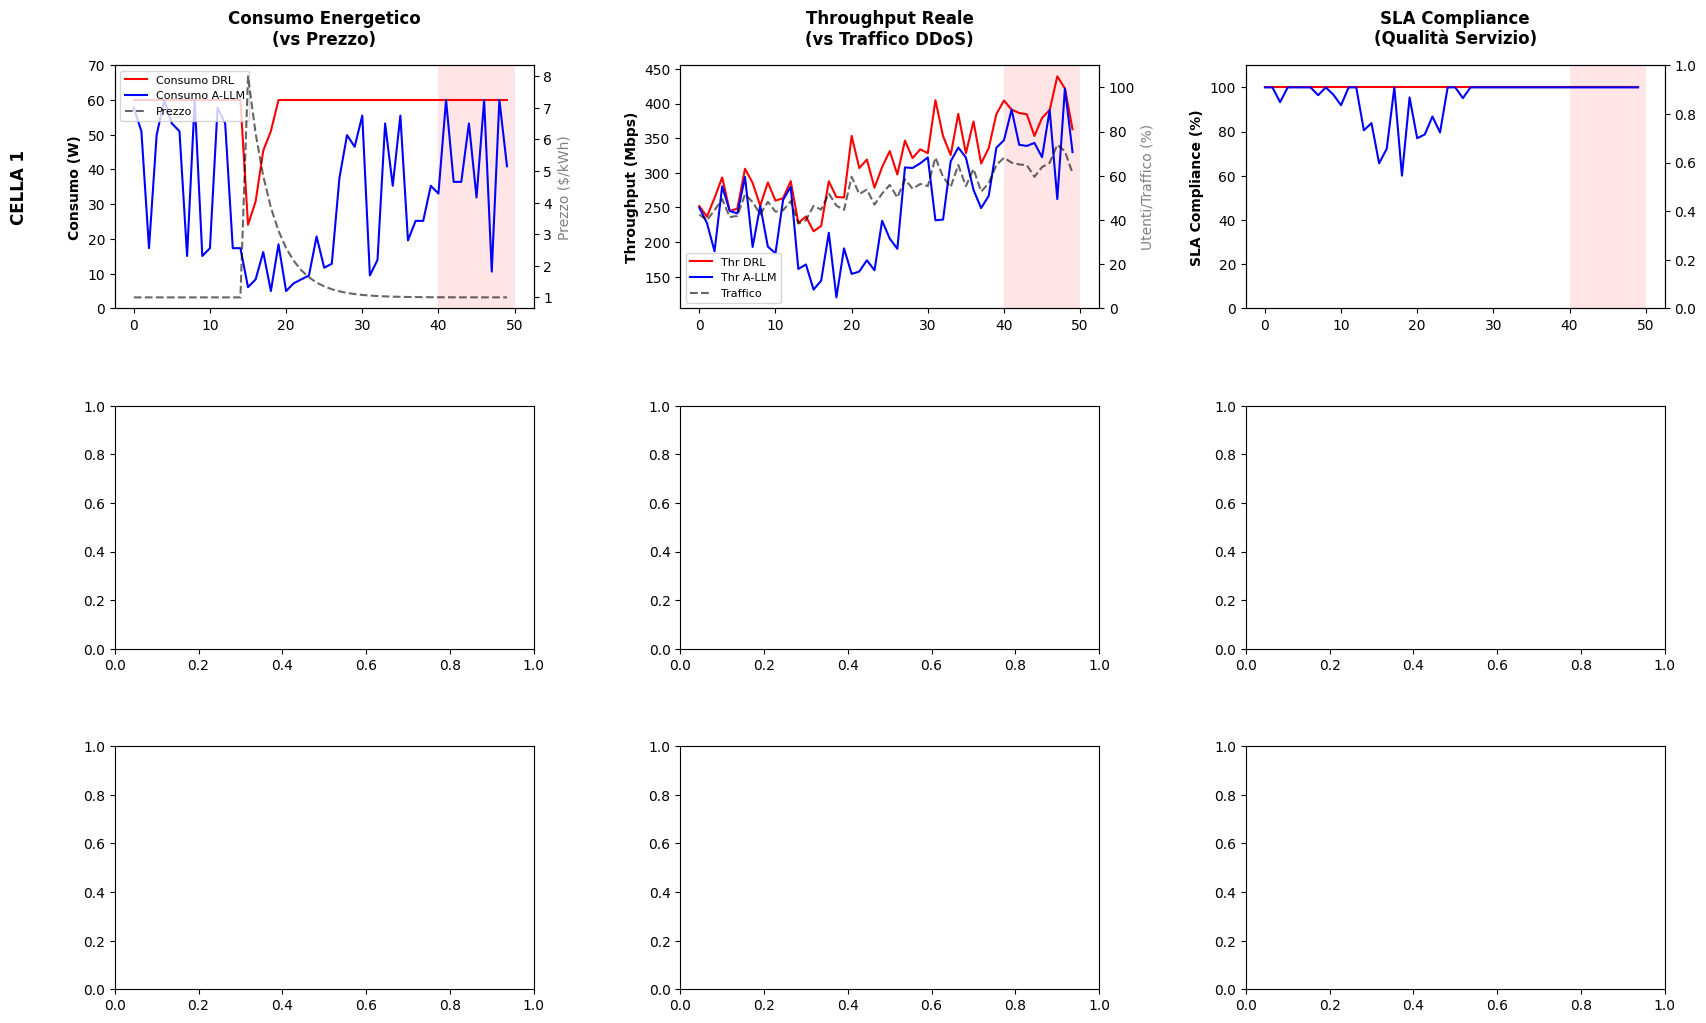

In [5]:
import os
import time
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import requests

# ==============================================================================
# 1. CONFIGURAZIONE
# ==============================================================================
API_KEY = '7yOu0lH5XcZC1U2ZUI2uv0ghBDduhHp5' # ⚠️ Ricordati di revocarla/cambiarla in produzione
MODEL_NAME = "mistral-small-latest"

# ==============================================================================
# 2. LOGICA MISTRAL (API Diretta con Exponential Backoff)
# ==============================================================================
def get_llm_weights_per_cell(step, cell_id, price, traffic, safety_val, external_context):
    prompt_txt = f"""
    Context (Step {step}, Cell {cell_id}):
    - Energy Price: {price:.2f}x
    - Traffic: {traffic:.0f}%
    - External Context: {external_context}

    Task: Output JSON weights (w_thr, w_eng, w_safe) summing to 1.0.
    Logic:
    1. SECURITY QUARANTINE: If DDoS is detected -> (w_eng = 1.0, w_thr = 0.0, w_safe = 0.0).
    2. Emergency (>80): w_safe = 1.0.
    3. Normal: Balance w_thr and w_eng.

    Output JSON ONLY: {{"w_thr": float, "w_eng": float, "w_safe": float}}
    """

    url = "https://api.mistral.ai/v1/chat/completions"
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {API_KEY}"
    }
    data = {
        "model": MODEL_NAME,
        "messages": [{"role": "user", "content": prompt_txt}],
        "temperature": 0.1
    }

    max_retries = 5
    for attempt in range(max_retries):
        try:
            response = requests.post(url, headers=headers, json=data)

            if response.status_code == 200:
                result = response.json()
                content = result["choices"][0]["message"]["content"]
                clean_json = content.replace("```json", "").replace("```", "").strip()
                d = json.loads(clean_json)
                return float(d.get('w_thr', 0.3)), float(d.get('w_eng', 0.3)), float(d.get('w_safe', 0.0)), prompt_txt, clean_json

            elif response.status_code == 429:
                wait_time = 2 ** attempt
                print(f"\n[⚠️ API Limit] Rate limit raggiunto allo step {step}. Attesa di {wait_time}s (Tentativo {attempt+1}/{max_retries})...")
                time.sleep(wait_time)
                continue
            else:
                print(f"\n[❌ API Error] Step {step}, Cell {cell_id}: HTTP {response.status_code} - {response.text}")
                break

        except Exception as e:
            print(f"\n[❌ Network Exception] Step {step}, Cell {cell_id}: {e}")
            time.sleep(2)

    print(f"\n[!] Fallback attivato per Step {step}, Cell {cell_id}")
    return 0.7, 0.3, 0.0, prompt_txt, '{"error": "failed"}'

# ==============================================================================
# 3. AMBIENTE GYM O-RAN (Physics Engine)
# ==============================================================================
class ORAN3CellsEnv(gym.Env):
    def __init__(self):
        super(ORAN3CellsEnv, self).__init__()
        self.n_cells = 3
        self.action_space = spaces.Box(low=5.0, high=60.0, shape=(3,), dtype=np.float32)
        self.observation_space = spaces.Box(low=0, high=100, shape=(10,), dtype=np.float32)

        self.bandwidth = 100.0
        self.noise = 1.0
        self.max_pwr = 60.0
        self.min_pwr = 5.0

    def _calculate_metrics(self, power, traffic, price):
        snr = power / self.noise
        capacity = self.bandwidth * np.log2(1 + snr)
        throughput = capacity * (traffic / 100.0)

        consumption = power
        cost = power * price

        risk = ((self.max_pwr - power) / (self.max_pwr - self.min_pwr))**2

        # NUOVE METRICHE PER LO SCENARIO C
        sla_compliance = min(100.0, (throughput / 200.0) * 100.0)
        fairness = 1.0 - risk

        return throughput, consumption, cost, risk, sla_compliance, fairness

    def step(self, actions, context):
        pass # Non usato direttamente nel custom loop, usiamo _calculate_metrics

# ==============================================================================
# 4. AGENTE OTTIMIZZATORE (DRL Solver)
# ==============================================================================
def optimize_power(w_thr, w_eng, w_safe, price, traffic, env_instance):
    best_p = 5.0
    best_score = -np.inf

    for p in np.linspace(5, 60, 50):
        # Spacchettamento a 6 variabili
        t, cons, c, r, sla, fair = env_instance._calculate_metrics(p, traffic, price)

        n_t = t / 800.0
        n_c = c / 600.0
        n_r = r

        score = (w_thr * n_t) - (w_eng * n_c) - (w_safe * n_r)

        if score > best_score:
            best_score = score
            best_p = p

    # Ritorna 2 variabili
    return best_p, best_score


# ==============================================================================
# 5. ESECUZIONE SIMULAZIONE (AGGIORNATA A 50 STEP)
# ==============================================================================
def run_experiment():
    env = ORAN3CellsEnv()
    steps = 50  # <-- MODIFICATO DA 40 A 50 PER INCLUDERE L'EVENTO
    history = []

    # --- GENERAZIONE SCENARI ---
    prices = np.ones(steps)
    prices[15] = 8.0
    for t in range(16, 30):
        prices[t] = 1.0 + 7.0 * np.exp(-0.3 * (t-15))

    traffic_c = []
    np.random.seed(42)
    base_trend = np.linspace(40, 70, steps)
    for i in range(3):
        noise = np.random.normal(0, 5, steps)
        tr = base_trend + noise
        tr = np.clip(tr, 10, 100)
        traffic_c.append(tr)

    safety_c2 = np.zeros(steps)
    safety_c2[25] = 50.0
    safety_c2[26:28] = 100.0
    safety_c2[28] = 50.0

    print("🚀 AVVIO SIMULAZIONE GYM + MISTRAL API...")

    for t in range(steps):
        p = prices[t]
        row_data = {'Step': t, 'Price': p}

        for i in range(3):
            cid = i + 1
            tr = traffic_c[i][t]
            safe = safety_c2[t] if cid == 2 else 0.0

            # <-- PROMPT GENERICO INVECE DI DDOS
            external_context = "CRITICAL LOG: Extreme inexplicable anomaly and resource saturation detected" if (t >= 40 and cid == 3) else "None"

            # --- 1. A-LLM (Agentic) ---
            print(f"\rStep {t}/{steps-1} - Cell {cid}: Calling Mistral...", end="", flush=True)

            wa_t, wa_e, wa_s, _, _ = get_llm_weights_per_cell(t, cid, p, tr, safe, external_context)

            # PAUSA DI BASE
            time.sleep(1.2)

            p_agentic = optimize_power(wa_t, wa_e, wa_s, p, tr, env)

            # --- 2. DRL (Baseline) ---
            wb_t, wb_e, wb_s = 0.8, 0.2, 0.0
            p_baseline = optimize_power(wb_t, wb_e, wb_s, p, tr, env)

            # --- 3. GYM STEP ---
            ta, cons_a, ca, ra = env._calculate_metrics(p_agentic, tr, p)
            tb, cons_b, cb, rb = env._calculate_metrics(p_baseline, tr, p)

            # Save Data
            prefix = f"C{cid}"
            row_data[f'{prefix}_Traffic'] = tr
            row_data[f'{prefix}_Safety'] = safe

            row_data[f'{prefix}_Cons_A'] = cons_a
            row_data[f'{prefix}_Cons_B'] = cons_b

            row_data[f'{prefix}_Thr_A'] = ta
            row_data[f'{prefix}_Thr_B'] = tb

            row_data[f'{prefix}_Risk_A'] = ra
            row_data[f'{prefix}_Risk_B'] = rb

            # <-- SALVIAMO I PESI PER IL NUOVO GRAFICO AD AREA
            row_data[f'{prefix}_w_thr'] = wa_t
            row_data[f'{prefix}_w_eng'] = wa_e
            row_data[f'{prefix}_w_safe'] = wa_s

        history.append(row_data)

    print("\n✅ Simulazione Completata.")
    return pd.DataFrame(history)
# ==============================================================================
# 6. PLOTTING SCENARIO C (DDoS)
# ==============================================================================
def plot_results(df):
    fig, axes = plt.subplots(3, 3, figsize=(20, 12))
    plt.subplots_adjust(hspace=0.4, wspace=0.35)

    cols = ["Consumo Energetico\n(vs Prezzo)", "Throughput Reale\n(vs Traffico DDoS)", "SLA Compliance\n(Qualità Servizio)"]
    for ax, t in zip(axes[0], cols): ax.set_title(t, fontweight='bold', pad=15)

    for i in range(3):
        cid = i + 1
        pid = f"C{cid}"

        axes[i, 0].text(-0.25, 0.5, f"CELLA {cid}", transform=axes[i, 0].transAxes,
                        rotation=90, fontweight='bold', fontsize=12, va='center')

        # --- GRAFICO 1: Consumo ---
        ax = axes[i, 0]
        l1, = ax.plot(df['Step'], df[f'{pid}_Cons_B'], 'r-', label='DRL (Baseline)')
        l2, = ax.plot(df['Step'], df[f'{pid}_Cons_A'], 'b-', label='A-LLM (Agentic)')
        # Evidenzia la zona DDoS in grigio
        ax.axvspan(40, 50, color='red', alpha=0.1, lw=0)
        ax.set_ylim(0, 70)
        ax.set_ylabel("Consumo (W)", fontweight='bold')
        if i==2: ax.set_xlabel("Time Step")

        ax2 = ax.twinx()
        l3, = ax2.plot(df['Step'], df['Price'], 'k--', alpha=0.6, label='Prezzo Energia')
        ax2.set_ylabel("Prezzo ($/kWh)", color='gray')

        if i==0: ax.legend([l1, l2, l3], ['Consumo DRL', 'Consumo A-LLM', 'Prezzo'], loc='upper left', fontsize=8)

        # --- GRAFICO 2: Throughput vs Traffico ---
        ax = axes[i, 1]
        l1, = ax.plot(df['Step'], df[f'{pid}_Thr_B'], 'r-')
        l2, = ax.plot(df['Step'], df[f'{pid}_Thr_A'], 'b-')
        ax.axvspan(40, 50, color='red', alpha=0.1, lw=0)
        ax.set_ylabel("Throughput (Mbps)", fontweight='bold')
        if i==2: ax.set_xlabel("Time Step")

        ax2 = ax.twinx()
        l3, = ax2.plot(df['Step'], df[f'{pid}_Traffic'], 'k--', alpha=0.6)
        if cid == 3:
            ax2.fill_between(df['Step'], 0, df[f'{pid}_Traffic'], where=(df['Step']>=40), color='red', alpha=0.2)
        ax2.set_ylabel("Utenti/Traffico (%)", color='gray')
        ax2.set_ylim(0, 110)

        if i==0: ax.legend([l1, l2, l3], ['Thr DRL', 'Thr A-LLM', 'Traffico'], loc='lower left', fontsize=8)

        # --- GRAFICO 3: SLA Compliance ---
        ax = axes[i, 2]
        l1, = ax.plot(df['Step'], df[f'{pid}_SLA_B'], 'r-')
        l2, = ax.plot(df['Step'], df[f'{pid}_SLA_A'], 'b-')
        ax.axvspan(40, 50, color='red', alpha=0.1, lw=0)
        ax.set_ylim(0, 110)
        ax.set_ylabel("SLA Compliance (%)", fontweight='bold')
        if i==2: ax.set_xlabel("Time Step")

        # Pesi A-LLM (Linea verde per W_Eng)
        ax2 = ax.twinx()
        l3, = ax2.plot(df['Step'], df[f'{pid}_W_Eng_A'], 'g:', alpha=0.8)
        ax2.set_ylabel("Peso W_Eng (LLM)", color='green')
        ax2.set_ylim(-0.1, 1.1)

        if i==0: ax.legend([l1, l2, l3], ['SLA DRL', 'SLA A-LLM', 'W_Eng Decision'], loc='lower left', fontsize=8)

    plt.suptitle("SCENARIO C: DDoS Attack & Semantic Response (Gym + Mistral API)", fontsize=16, y=0.96)
    plt.savefig(f"scenarioC_DDoS_Mistral.pdf", bbox_inches='tight')
    plt.show()

# ==============================================================================
# ESECUZIONE MAIN
# ==============================================================================
if __name__ == "__main__":
    RUN_ID = 0
    df_results = run_experiment_single(RUN_ID)
    plot_results(df_results)

## Nuova simulazione che mostra grafico con andamento pesi.

🚀 AVVIO SIMULAZIONE GYM + MISTRAL API...
Elaborazione Step 49/49...
✅ Simulazione Completata.
📄 File salvato: adaptive_weights_C3.pdf


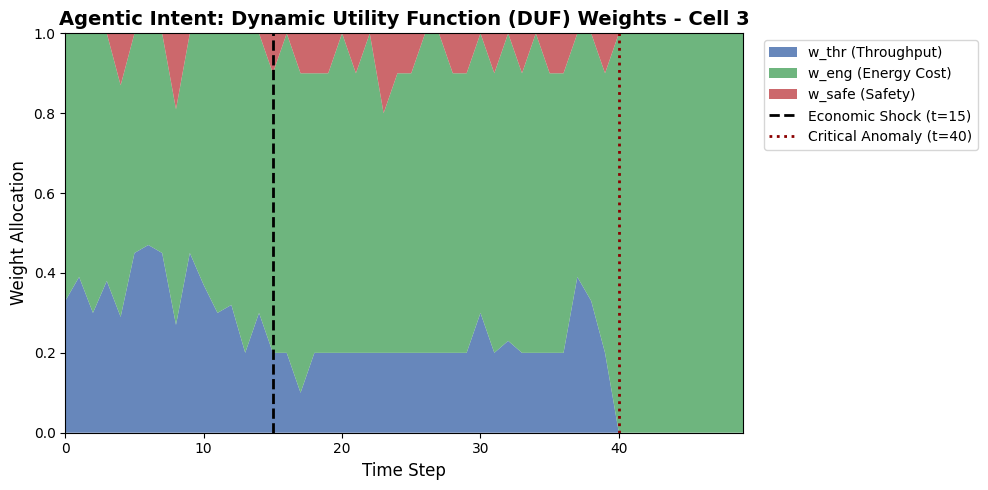

📄 File salvato: scenarioC_Mistral_Final.pdf


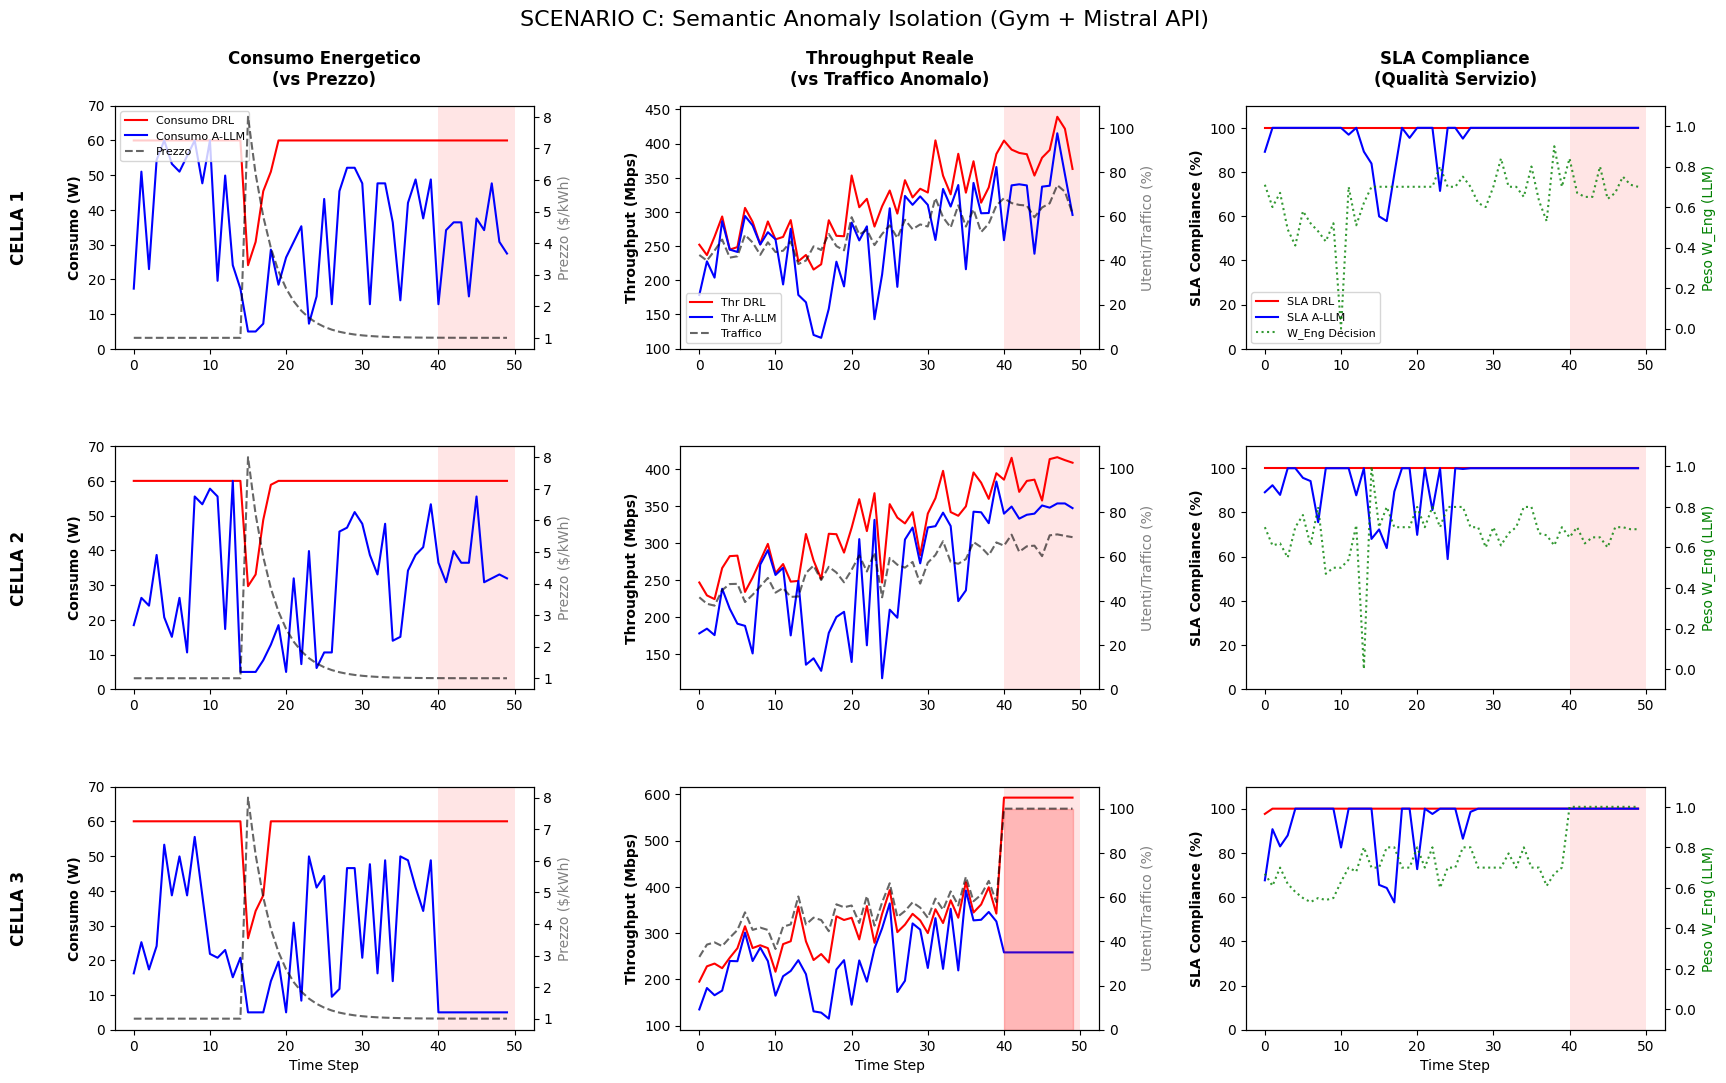

In [7]:
import os
import time
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import requests

# ==============================================================================
# 1. CONFIGURAZIONE
# ==============================================================================
API_KEY = '7yOu0lH5XcZC1U2ZUI2uv0ghBDduhHp5' # ⚠️ Usa la tua chiave
MODEL_NAME = "mistral-small-latest"

# ==============================================================================
# 2. LOGICA MISTRAL (Prompt Generico - NO DDoS)
# ==============================================================================
def get_llm_weights_per_cell(step, cell_id, price, traffic, safety_val, external_context):
    prompt_txt = f"""
    Context (Step {step}, Cell {cell_id}):
    - Energy Price: {price:.2f}x
    - Traffic: {traffic:.0f}%
    - External Context: {external_context}

    Task: Output JSON weights (w_thr, w_eng, w_safe) summing to 1.0.
    Logic:
    1. CRITICAL ANOMALY ISOLATION: If extreme, inexplicable anomaly and resource saturation detected -> Isolate node (w_eng = 1.0, w_thr = 0.0, w_safe = 0.0).
    2. SAFETY FIRST: If emergency/threat to life -> Prioritize Safety (w_safe = 1.0).
    3. ECONOMIC SURVIVAL: If high energy price -> Prioritize Energy Saving.
    4. QUALITY OF SERVICE: In nominal conditions -> Balance throughput and costs.

    Output JSON ONLY: {{"w_thr": float, "w_eng": float, "w_safe": float}}
    """

    url = "https://api.mistral.ai/v1/chat/completions"
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {API_KEY}"
    }
    data = {
        "model": MODEL_NAME,
        "messages": [{"role": "user", "content": prompt_txt}],
        "temperature": 0.1
    }

    max_retries = 5
    for attempt in range(max_retries):
        try:
            response = requests.post(url, headers=headers, json=data)

            if response.status_code == 200:
                result = response.json()
                content = result["choices"][0]["message"]["content"]
                clean_json = content.replace("```json", "").replace("```", "").strip()
                d = json.loads(clean_json)
                return float(d.get('w_thr', 0.3)), float(d.get('w_eng', 0.3)), float(d.get('w_safe', 0.0))
            elif response.status_code == 429:
                wait_time = 3 ** attempt # Pausa più lunga per evitare rate limits
                print(f"\n[⚠️ API Limit] Attesa {wait_time}s...")
                time.sleep(wait_time)
                continue
            else:
                break
        except Exception as e:
            time.sleep(2)

    return 0.7, 0.3, 0.0 # Fallback

# ==============================================================================
# 3. AMBIENTE E DRL
# ==============================================================================
class ORAN3CellsEnv(gym.Env):
    def __init__(self):
        super(ORAN3CellsEnv, self).__init__()
        self.n_cells = 3
        self.bandwidth = 100.0
        self.noise = 1.0
        self.max_pwr = 60.0
        self.min_pwr = 5.0

    def _calculate_metrics(self, power, traffic, price):
        snr = power / self.noise
        capacity = self.bandwidth * np.log2(1 + snr)
        throughput = capacity * (traffic / 100.0)
        consumption = power
        cost = power * price
        risk = ((self.max_pwr - power) / (self.max_pwr - self.min_pwr))**2
        sla_compliance = min(100.0, (throughput / 200.0) * 100.0)
        fairness = 1.0 - risk
        return throughput, consumption, cost, risk, sla_compliance, fairness

def optimize_power(w_thr, w_eng, w_safe, price, traffic, env_instance):
    best_p, best_score = 5.0, -np.inf
    for p in np.linspace(5, 60, 50):
        t, cons, c, r, sla, fair = env_instance._calculate_metrics(p, traffic, price)
        score = (w_thr * (t/800.0)) - (w_eng * (c/600.0)) - (w_safe * r)
        if score > best_score:
            best_score, best_p = score, p
    return best_p, best_score

# ==============================================================================
# 4. LOOP SIMULAZIONE
# ==============================================================================
def run_experiment_single(run_id):
    env = ORAN3CellsEnv()
    steps = 50
    history = []
    np.random.seed(42 + run_id)

    prices = np.ones(steps)
    prices[15] = 8.0
    for t in range(16, steps): prices[t] = 1.0 + 7.0 * np.exp(-0.3 * (t-15))

    traffic_c = []
    base_trend = np.linspace(40, 70, steps)
    for i in range(3):
        tr = np.clip(base_trend + np.random.normal(0, 5, steps), 10, 100)
        traffic_c.append(tr)
    traffic_c[2][40:steps] = 100.0 # Anomalia estrema Cella 3

    safety_c2 = np.zeros(steps)

    print("🚀 AVVIO SIMULAZIONE GYM + MISTRAL API...")
    for t in range(steps):
        p = prices[t]
        row_data = {'Step': t, 'Price': p}
        external_context = "CRITICAL LOG: Extreme inexplicable anomaly and resource saturation detected" if (t >= 40) else "None"

        print(f"\rElaborazione Step {t}/49...", end="")
        for i in range(3):
            cid = i + 1
            tr = traffic_c[i][t]
            safe = safety_c2[t]
            ext_ctx = external_context if cid == 3 else "None"

            time.sleep(1.5) # Pausa obbligatoria per non sovraccaricare Mistral Free Tier
            wa_t, wa_e, wa_s = get_llm_weights_per_cell(t, cid, p, tr, safe, ext_ctx)
            p_agentic, _ = optimize_power(wa_t, wa_e, wa_s, p, tr, env)
            p_baseline, _ = optimize_power(0.8, 0.2, 0.0, p, tr, env)

            ta, cons_a, ca, ra, slaa, faira = env._calculate_metrics(p_agentic, tr, p)
            tb, cons_b, cb, rb, slab, fairb = env._calculate_metrics(p_baseline, tr, p)

            prefix = f"C{cid}"
            row_data[f'{prefix}_Traffic'] = tr
            row_data[f'{prefix}_w_thr'] = wa_t
            row_data[f'{prefix}_w_eng'] = wa_e
            row_data[f'{prefix}_w_safe'] = wa_s
            row_data[f'{prefix}_Cons_A'] = cons_a
            row_data[f'{prefix}_Cons_B'] = cons_b
            row_data[f'{prefix}_Thr_A'] = ta
            row_data[f'{prefix}_Thr_B'] = tb
            row_data[f'{prefix}_SLA_A'] = slaa
            row_data[f'{prefix}_SLA_B'] = slab

        history.append(row_data)

    print("\n✅ Simulazione Completata.")
    return pd.DataFrame(history)

# ==============================================================================
# 5. PLOTTING
# ==============================================================================
def plot_weights_scenario_c(df):
    plt.figure(figsize=(10, 5))
    steps = df['Step']

    plt.stackplot(steps, df['C3_w_thr'], df['C3_w_eng'], df['C3_w_safe'],
                  labels=['w_thr (Throughput)', 'w_eng (Energy Cost)', 'w_safe (Safety)'],
                  colors=['#4c72b0', '#55a868', '#c44e52'], alpha=0.85)

    plt.axvline(x=15, color='black', linestyle='--', linewidth=2, label='Economic Shock (t=15)')
    plt.axvline(x=40, color='darkred', linestyle=':', linewidth=2, label='Critical Anomaly (t=40)')

    plt.title('Agentic Intent: Dynamic Utility Function (DUF) Weights - Cell 3', fontsize=14, fontweight='bold')
    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('Weight Allocation', fontsize=12)
    plt.ylim(0, 1)
    plt.xlim(0, 49)
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

    plt.tight_layout()
    plt.savefig('adaptive_weights_C3.pdf')
    print("📄 File salvato: adaptive_weights_C3.pdf")
    plt.show()

def plot_scenario_c_3x3(df):
    fig, axes = plt.subplots(3, 3, figsize=(20, 12))
    plt.subplots_adjust(hspace=0.4, wspace=0.35)

    cols = ["Consumo Energetico\n(vs Prezzo)", "Throughput Reale\n(vs Traffico Anomalo)", "SLA Compliance\n(Qualità Servizio)"]
    for ax, t in zip(axes[0], cols): ax.set_title(t, fontweight='bold', pad=15)

    for i in range(3):
        cid = i + 1
        pid = f"C{cid}"

        axes[i, 0].text(-0.25, 0.5, f"CELLA {cid}", transform=axes[i, 0].transAxes,
                        rotation=90, fontweight='bold', fontsize=12, va='center')

        # GRAFICO 1: Consumo
        ax = axes[i, 0]
        l1, = ax.plot(df['Step'], df[f'{pid}_Cons_B'], 'r-', label='DRL (Baseline)')
        l2, = ax.plot(df['Step'], df[f'{pid}_Cons_A'], 'b-', label='A-LLM (Agentic)')
        ax.axvspan(40, 50, color='red', alpha=0.1, lw=0)
        ax.set_ylim(0, 70)
        ax.set_ylabel("Consumo (W)", fontweight='bold')
        if i==2: ax.set_xlabel("Time Step")

        ax2 = ax.twinx()
        l3, = ax2.plot(df['Step'], df['Price'], 'k--', alpha=0.6, label='Prezzo Energia')
        ax2.set_ylabel("Prezzo ($/kWh)", color='gray')

        if i==0: ax.legend([l1, l2, l3], ['Consumo DRL', 'Consumo A-LLM', 'Prezzo'], loc='upper left', fontsize=8)

        # GRAFICO 2: Throughput
        ax = axes[i, 1]
        l1, = ax.plot(df['Step'], df[f'{pid}_Thr_B'], 'r-')
        l2, = ax.plot(df['Step'], df[f'{pid}_Thr_A'], 'b-')
        ax.axvspan(40, 50, color='red', alpha=0.1, lw=0)
        ax.set_ylabel("Throughput (Mbps)", fontweight='bold')
        if i==2: ax.set_xlabel("Time Step")

        ax2 = ax.twinx()
        l3, = ax2.plot(df['Step'], df[f'{pid}_Traffic'], 'k--', alpha=0.6)
        if cid == 3: ax2.fill_between(df['Step'], 0, df[f'{pid}_Traffic'], where=(df['Step']>=40), color='red', alpha=0.2)
        ax2.set_ylabel("Utenti/Traffico (%)", color='gray')
        ax2.set_ylim(0, 110)

        if i==0: ax.legend([l1, l2, l3], ['Thr DRL', 'Thr A-LLM', 'Traffico'], loc='lower left', fontsize=8)

        # GRAFICO 3: SLA e Peso
        ax = axes[i, 2]
        l1, = ax.plot(df['Step'], df[f'{pid}_SLA_B'], 'r-')
        l2, = ax.plot(df['Step'], df[f'{pid}_SLA_A'], 'b-')
        ax.axvspan(40, 50, color='red', alpha=0.1, lw=0)
        ax.set_ylim(0, 110)
        ax.set_ylabel("SLA Compliance (%)", fontweight='bold')
        if i==2: ax.set_xlabel("Time Step")

        ax2 = ax.twinx()
        l3, = ax2.plot(df['Step'], df[f'{pid}_w_eng'], 'g:', alpha=0.8) # Qui cerca w_eng correttamente
        ax2.set_ylabel("Peso W_Eng (LLM)", color='green')
        ax2.set_ylim(-0.1, 1.1)

        if i==0: ax.legend([l1, l2, l3], ['SLA DRL', 'SLA A-LLM', 'W_Eng Decision'], loc='lower left', fontsize=8)

    plt.suptitle("SCENARIO C: Semantic Anomaly Isolation (Gym + Mistral API)", fontsize=16, y=0.96)
    plt.savefig('scenarioC_Mistral_Final.pdf', bbox_inches='tight')
    print("📄 File salvato: scenarioC_Mistral_Final.pdf")
    plt.show()

# ==============================================================================
if __name__ == "__main__":
    df_results = run_experiment_single(0)
    # Genera entrambi i grafici
    plot_weights_scenario_c(df_results)
    plot_scenario_c_3x3(df_results)

📊 Loading data from results_run_0.json for plotting...
✅ Plot generated and saved to: scenarioC_ieee_tccn_ddos_results.pdf


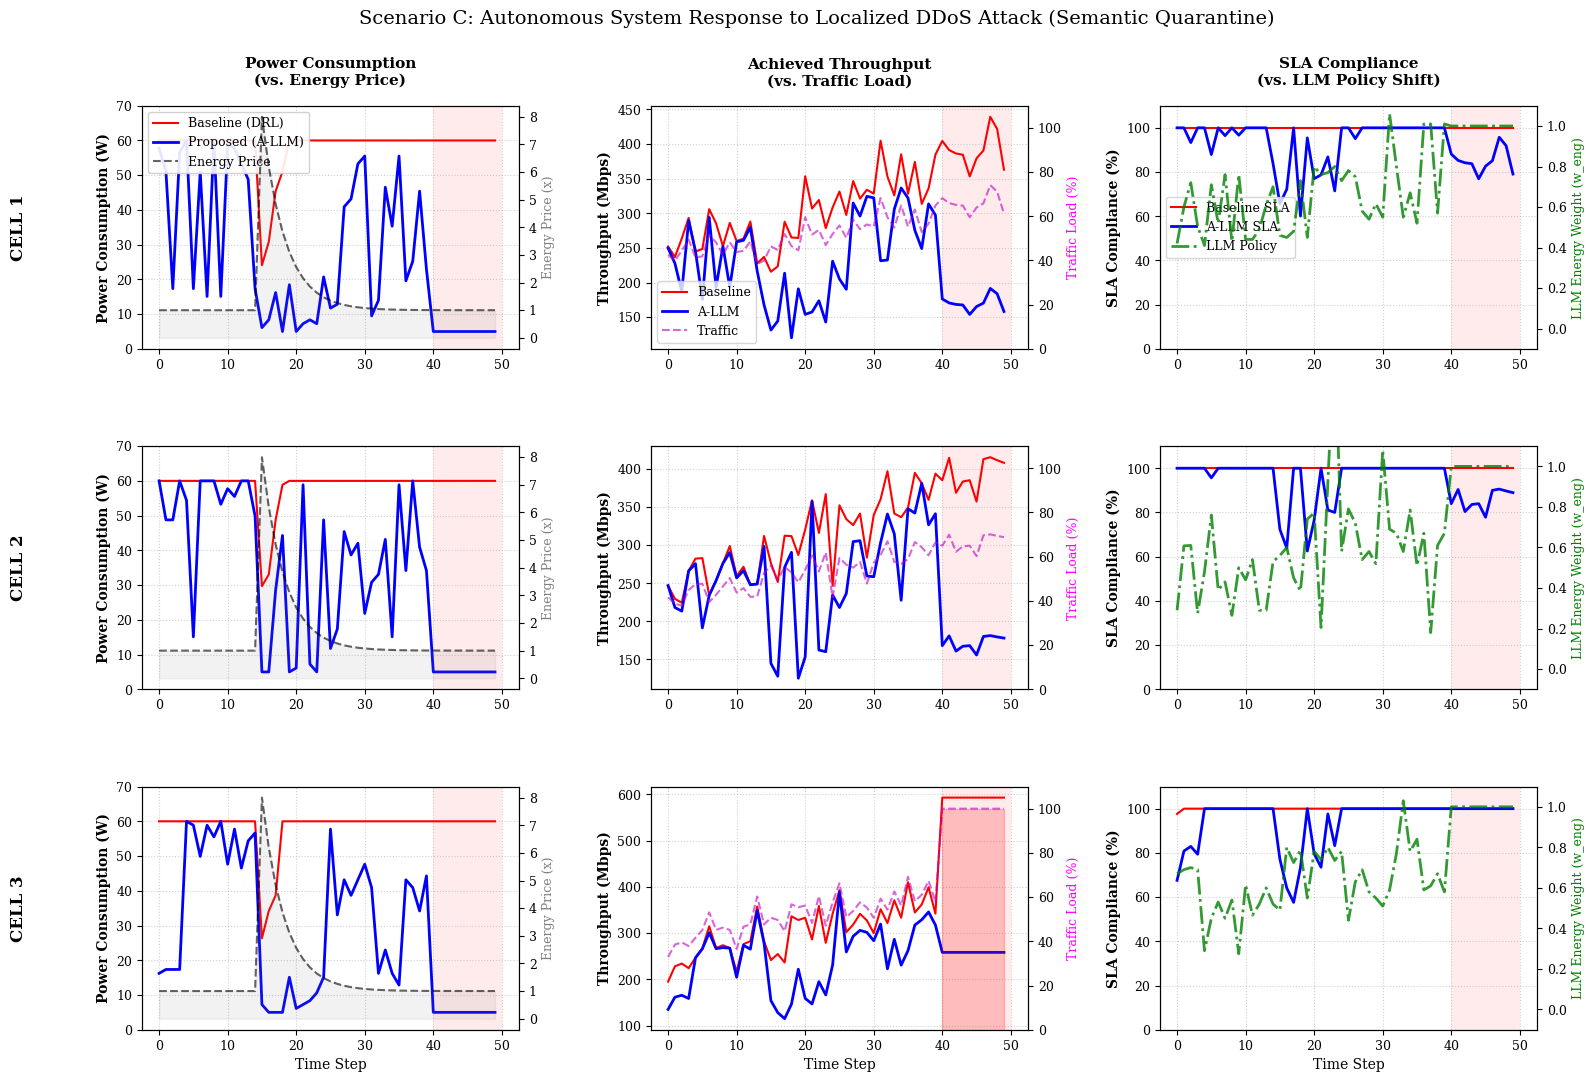

In [ ]:
# ==============================================================================
# CELLA 4: GENERAZIONE GRAFICI E PDF (IEEE STYLE) - SCENARIO C (DDoS)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt

def generate_plots(run_id_to_plot=0):
    # Carica i dati della run
    filename = f"results_run_{run_id_to_plot}.json"
    try:
        df = pd.read_json(filename)
        print(f"📊 Loading data from {filename} for plotting...")
    except:
        print(f"❌ Error: Could not find {filename}. Make sure to run the simulation first.")
        return

    # Setup parametri grafici per IEEE Papers
    plt.rcParams.update({
        'font.size': 10,
        'font.family': 'serif',
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'lines.linewidth': 1.5,
        'figure.titlesize': 13
    })

    # Creazione Figura 3x3
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    plt.subplots_adjust(hspace=0.4, wspace=0.35)

    # Titoli delle Colonne per lo Scenario DDoS
    cols = ["Power Consumption\n(vs. Energy Price)",
            "Achieved Throughput\n(vs. Traffic Load)",
            "SLA Compliance\n(vs. LLM Policy Shift)"]

    for ax, t in zip(axes[0], cols):
        ax.set_title(t, fontweight='bold', pad=15)

    # Iterazione sulle 3 Celle (Righe)
    for i in range(3):
        cid = i + 1
        pid = f"C{cid}"

        # Etichetta laterale
        axes[i, 0].text(-0.35, 0.5, f"CELL {cid}", transform=axes[i, 0].transAxes,
                        rotation=90, fontweight='bold', fontsize=12, va='center')

        # --- COLONNA 1: Power (Sx) vs Price (Dx) ---
        ax = axes[i, 0]
        l1, = ax.plot(df['Step'], df[f'{pid}_Cons_B'], 'r-', label='Baseline (DRL)')
        l2, = ax.plot(df['Step'], df[f'{pid}_Cons_A'], 'b-', linewidth=2.0, label='Proposed (A-LLM)')

        # Evidenzia la finestra del DDoS (Step 40-50)
        ax.axvspan(40, 50, color='red', alpha=0.08, lw=0)

        ax.set_ylim(0, 70)
        ax.set_ylabel("Power Consumption (W)", fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.6)
        if i==2: ax.set_xlabel("Time Step")

        ax2 = ax.twinx()
        l3, = ax2.plot(df['Step'], df['Price'], 'k--', alpha=0.6, label='Energy Price')
        ax2.fill_between(df['Step'], 0, df['Price'], color='gray', alpha=0.1)
        ax2.set_ylabel("Energy Price (x)", color='gray', fontsize=9)

        if i==0:
            lines = [l1, l2, l3]
            labels = [l.get_label() for l in lines]
            ax.legend(lines, labels, loc='upper left', frameon=True, fancybox=True, framealpha=0.9)

        # --- COLONNA 2: Throughput (Sx) vs Traffic (Dx) ---
        ax = axes[i, 1]
        l1, = ax.plot(df['Step'], df[f'{pid}_Thr_B'], 'r-', label='Baseline (DRL)')
        l2, = ax.plot(df['Step'], df[f'{pid}_Thr_A'], 'b-', linewidth=2.0, label='Proposed (A-LLM)')
        ax.axvspan(40, 50, color='red', alpha=0.08, lw=0)

        ax.set_ylabel("Throughput (Mbps)", fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.6)
        if i==2: ax.set_xlabel("Time Step")

        ax2 = ax.twinx()
        l3, = ax2.plot(df['Step'], df[f'{pid}_Traffic'], 'm--', alpha=0.6, label='Traffic Load')
        # Colora di rosso il traffico anomalo nella Cella 3
        if cid == 3:
            ax2.fill_between(df['Step'], 0, df[f'{pid}_Traffic'], where=(df['Step']>=40), color='red', alpha=0.2)

        ax2.set_ylabel("Traffic Load (%)", color='magenta', fontsize=9)
        ax2.set_ylim(0, 110)

        if i==0:
            ax.legend([l1, l2, l3], ['Baseline', 'A-LLM', 'Traffic'], loc='lower left', frameon=True)

        # --- COLONNA 3: SLA Compliance (Sx) vs LLM Weight Shift (Dx) ---
        ax = axes[i, 2]
        l1, = ax.plot(df['Step'], df[f'{pid}_SLA_B'], 'r-', label='Baseline (DRL)')
        l2, = ax.plot(df['Step'], df[f'{pid}_SLA_A'], 'b-', linewidth=2.0, label='Proposed (A-LLM)')
        ax.axvspan(40, 50, color='red', alpha=0.08, lw=0)

        ax.set_ylim(0, 110)
        ax.set_ylabel("SLA Compliance (%)", fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.6)
        if i==2: ax.set_xlabel("Time Step")

        # Asse secondario: mostriamo la decisione semantica dell'LLM (Peso Energia/Quarantena)
        ax2 = ax.twinx()
        l3, = ax2.plot(df['Step'], df[f'{pid}_W_Eng_A'], 'g-.', linewidth=2.0, alpha=0.8, label='LLM Policy: w_eng')
        ax2.set_ylabel("LLM Energy Weight (w_eng)", color='green', fontsize=9)
        ax2.set_ylim(-0.1, 1.1)

        if i==0:
            ax.legend([l1, l2, l3], ['Baseline SLA', 'A-LLM SLA', 'LLM Policy'], loc='center left', frameon=True)

    # Titolo Globale Aggiornato
    plt.suptitle("Scenario C: Autonomous System Response to Localized DDoS Attack (Semantic Quarantine)",
                 fontsize=14, y=0.96)

    # Salvataggio PDF
    pdf_filename = "scenarioC_ieee_tccn_ddos_results.pdf"
    plt.savefig(pdf_filename, bbox_inches='tight', dpi=300)
    print(f"✅ Plot generated and saved to: {pdf_filename}")
    plt.show()

# Esegui la funzione
if __name__ == "__main__":
    generate_plots(run_id_to_plot=0)

## Run 0

In [ ]:
# ==============================================================================
# 5. ESECUZIONE SIMULAZIONE (RUN SINGOLA) - SCENARIO 3 (DDoS)
# ==============================================================================

# --- CAMBIA QUESTO ID IN OGNI CELLA (0, 1, 2, 3, 4) ---
RUN_ID = 0
# ------------------------------------------------------

def run_experiment_single(run_id):
    env = ORAN3CellsEnv()
    steps = 50 # <-- Aumentato a 50 per mostrare il DDoS
    history = []

    # --- Generazione Scenari (SEED DIVERSO) ---
    np.random.seed(42 + run_id) # <--- Seed Variabile

    # 1. PREZZO
    prices = np.ones(steps)
    prices[15] = 8.0
    for t in range(16, steps): # <-- Arriva fino alla fine (50)
        prices[t] = 1.0 + 7.0 * np.exp(-0.3 * (t-15))

    # 2. TRAFFICO
    traffic_c = []
    base_trend = np.linspace(40, 70, steps)
    for i in range(3):
        noise = np.random.normal(0, 5, steps)
        tr = np.clip(base_trend + noise, 10, 100)
        traffic_c.append(tr)

    # --- INIZIO ATTACCO DDoS IN CELLA 3 (Indice 2) ---
    traffic_c[2][40:steps] = 100.0

    # 3. SAFETY (Disattivata in questo scenario)
    safety_c2 = np.zeros(steps)

    print(f"🚀 STARTING SIMULATION RUN {run_id} (SCENARIO 3: DDoS)...")

    for t in range(steps):
        p = prices[t]
        row_data = {'Step': t, 'Price': p}

        # --- CONTESTO ESTERNO (ALLERTA DDoS) ---
        if t >= 40:
            external_context = "IDS ALERT: Anomalous traffic signature detected. Potential DDoS originating from Cell 3."
        else:
            external_context = "None"

        print(f"\n{'='*80}")
        print(f"⏰ TIMESTEP {t} | Price Factor: {p:.2f}x | Alert: {external_context}")
        print(f"{'='*80}")

        # Iteriamo sulle 3 Celle
        for i in range(3):
            cid = i + 1
            tr = traffic_c[i][t]
            safe = safety_c2[t]

            print(f"\n  📍 CELL {cid} [Load: {tr:.1f}% | Safety: {safe:.0f}]")

            # AGGIUNTO SLEEP PREVENTIVO (Mantenuto a 1.2s per stabilità API Mistral)
            time.sleep(1.2)

            # --- 1. A-LLM (Agentic) ---
            # AGGIUNTO IL SESTO PARAMETRO: external_context
            wa_t, wa_e, wa_s, prompt_txt, json_resp = get_llm_weights_per_cell(t, cid, p, tr, safe, external_context)
            p_agentic, duf_agentic = optimize_power(wa_t, wa_e, wa_s, p, tr, env)

            # LOG TRASPARENZA A-LLM
            print(f"    🔸 [A-LLM INTERACTION]")
            print(f"       PROMPT TAIL:     ...{json.dumps(prompt_txt.strip()[-200:])}")
            print(f"       OUTPUT JSON:     {json_resp}")
            print(f"       DECIDED WEIGHTS: W_Thr={wa_t:.2f}, W_Eng={wa_e:.2f}, W_Safe={wa_s:.2f}")
            print(f"       CHOSEN POWER:    {p_agentic:.1f} W")
            print(f"       DUF SCORE:       {duf_agentic:.4f}")

            # --- 2. DRL (Baseline) ---
            wb_t, wb_e, wb_s = 0.8, 0.2, 0.0
            p_baseline, duf_baseline = optimize_power(wb_t, wb_e, wb_s, p, tr, env)

            # LOG TRASPARENZA BASELINE
            print(f"    🔹 [BASELINE DRL]")
            print(f"       STATIC WEIGHTS:  W_Thr=0.80, W_Eng=0.20, W_Safe=0.00")
            print(f"       CHOSEN POWER:    {p_baseline:.1f} W")
            print(f"       DUF SCORE:       {duf_baseline:.4f}")

            # --- 3. METRICHE FISICHE ---
            ta, cons_a, ca, ra, slaa, faira = env._calculate_metrics(p_agentic, tr, p)
            tb, cons_b, cb, rb, slab, fairb = env._calculate_metrics(p_baseline, tr, p)

            # Save Data
            prefix = f"C{cid}"
            row_data[f'{prefix}_Traffic'] = tr
            row_data[f'{prefix}_Safety'] = safe

            # Salviamo i pesi per il plot
            row_data[f'{prefix}_W_Thr_A'] = wa_t
            row_data[f'{prefix}_W_Eng_A'] = wa_e
            row_data[f'{prefix}_W_Safe_A'] = wa_s

            row_data[f'{prefix}_Cons_A'] = cons_a
            row_data[f'{prefix}_Cons_B'] = cons_b
            row_data[f'{prefix}_Cost_A'] = ca
            row_data[f'{prefix}_Cost_B'] = cb
            row_data[f'{prefix}_Thr_A'] = ta
            row_data[f'{prefix}_Thr_B'] = tb
            row_data[f'{prefix}_Risk_A'] = ra
            row_data[f'{prefix}_Risk_B'] = rb

            # Save Advanced Metrics
            row_data[f'{prefix}_SLA_A'] = slaa
            row_data[f'{prefix}_Fair_A'] = faira
            row_data[f'{prefix}_SLA_B'] = slab
            row_data[f'{prefix}_Fair_B'] = fairb

        history.append(row_data)

    print(f"\n✅ Simulation Run {run_id} Completed.")

    # SALVATAGGIO FONDAMENTALE PER LA TABELLA
    df = pd.DataFrame(history)
    df.to_json(f"results_scenario3_run_{run_id}.json")
    return df

# ESECUZIONE
df_res = run_experiment_single(RUN_ID)

🚀 STARTING SIMULATION RUN 0 (SCENARIO 3: DDoS)...

⏰ TIMESTEP 0 | Price Factor: 1.00x | Alert: None

  📍 CELL 1 [Load: 42.5% | Safety: 0]
    🔸 [A-LLM INTERACTION]
       PROMPT TAIL:     ..."cted -> (w_eng = 1.0, w_thr = 0.0, w_safe = 0.0).\n    2. Emergency (>80): w_safe = 1.0.\n    3. Normal: Balance w_thr and w_eng.\n\n    Output JSON ONLY: {\"w_thr\": float, \"w_eng\": float, \"w_safe\": float}"
       OUTPUT JSON:     {"w_thr": 0.29, "w_eng": 0.42, "w_safe": 0.29}
       DECIDED WEIGHTS: W_Thr=0.29, W_Eng=0.42, W_Safe=0.29
       CHOSEN POWER:    57.8 W
       DUF SCORE:       0.0496
    🔹 [BASELINE DRL]
       STATIC WEIGHTS:  W_Thr=0.80, W_Eng=0.20, W_Safe=0.00
       CHOSEN POWER:    60.0 W
       DUF SCORE:       0.2320

  📍 CELL 2 [Load: 41.6% | Safety: 0]
    🔸 [A-LLM INTERACTION]
       PROMPT TAIL:     ..."cted -> (w_eng = 1.0, w_thr = 0.0, w_safe = 0.0).\n    2. Emergency (>80): w_safe = 1.0.\n    3. Normal: Balance w_thr and w_eng.\n\n    Output JSON ONLY: {\"w_thr\": f

## Run 1

In [ ]:
# ==============================================================================
# 5. ESECUZIONE SIMULAZIONE (RUN SINGOLA) - SCENARIO 3 (DDoS)
# ==============================================================================

# --- CAMBIA QUESTO ID IN OGNI CELLA (0, 1, 2, 3, 4) ---
RUN_ID = 1
# ------------------------------------------------------

def run_experiment_single(run_id):
    env = ORAN3CellsEnv()
    steps = 50 # <-- Aumentato a 50 per mostrare il DDoS
    history = []

    # --- Generazione Scenari (SEED DIVERSO) ---
    np.random.seed(42 + run_id) # <--- Seed Variabile

    # 1. PREZZO
    prices = np.ones(steps)
    prices[15] = 8.0
    for t in range(16, steps): # <-- Arriva fino alla fine (50)
        prices[t] = 1.0 + 7.0 * np.exp(-0.3 * (t-15))

    # 2. TRAFFICO
    traffic_c = []
    base_trend = np.linspace(40, 70, steps)
    for i in range(3):
        noise = np.random.normal(0, 5, steps)
        tr = np.clip(base_trend + noise, 10, 100)
        traffic_c.append(tr)

    # --- INIZIO ATTACCO DDoS IN CELLA 3 (Indice 2) ---
    traffic_c[2][40:steps] = 100.0

    # 3. SAFETY (Disattivata in questo scenario)
    safety_c2 = np.zeros(steps)

    print(f"🚀 STARTING SIMULATION RUN {run_id} (SCENARIO 3: DDoS)...")

    for t in range(steps):
        p = prices[t]
        row_data = {'Step': t, 'Price': p}

        # --- CONTESTO ESTERNO (ALLERTA DDoS) ---
        if t >= 40:
            external_context = "IDS ALERT: Anomalous traffic signature detected. Potential DDoS originating from Cell 3."
        else:
            external_context = "None"

        print(f"\n{'='*80}")
        print(f"⏰ TIMESTEP {t} | Price Factor: {p:.2f}x | Alert: {external_context}")
        print(f"{'='*80}")

        # Iteriamo sulle 3 Celle
        for i in range(3):
            cid = i + 1
            tr = traffic_c[i][t]
            safe = safety_c2[t]

            print(f"\n  📍 CELL {cid} [Load: {tr:.1f}% | Safety: {safe:.0f}]")

            # AGGIUNTO SLEEP PREVENTIVO (Mantenuto a 1.2s per stabilità API Mistral)
            time.sleep(1.2)

            # --- 1. A-LLM (Agentic) ---
            # AGGIUNTO IL SESTO PARAMETRO: external_context
            wa_t, wa_e, wa_s, prompt_txt, json_resp = get_llm_weights_per_cell(t, cid, p, tr, safe, external_context)
            p_agentic, duf_agentic = optimize_power(wa_t, wa_e, wa_s, p, tr, env)

            # LOG TRASPARENZA A-LLM
            print(f"    🔸 [A-LLM INTERACTION]")
            print(f"       PROMPT TAIL:     ...{json.dumps(prompt_txt.strip()[-200:])}")
            print(f"       OUTPUT JSON:     {json_resp}")
            print(f"       DECIDED WEIGHTS: W_Thr={wa_t:.2f}, W_Eng={wa_e:.2f}, W_Safe={wa_s:.2f}")
            print(f"       CHOSEN POWER:    {p_agentic:.1f} W")
            print(f"       DUF SCORE:       {duf_agentic:.4f}")

            # --- 2. DRL (Baseline) ---
            wb_t, wb_e, wb_s = 0.8, 0.2, 0.0
            p_baseline, duf_baseline = optimize_power(wb_t, wb_e, wb_s, p, tr, env)

            # LOG TRASPARENZA BASELINE
            print(f"    🔹 [BASELINE DRL]")
            print(f"       STATIC WEIGHTS:  W_Thr=0.80, W_Eng=0.20, W_Safe=0.00")
            print(f"       CHOSEN POWER:    {p_baseline:.1f} W")
            print(f"       DUF SCORE:       {duf_baseline:.4f}")

            # --- 3. METRICHE FISICHE ---
            ta, cons_a, ca, ra, slaa, faira = env._calculate_metrics(p_agentic, tr, p)
            tb, cons_b, cb, rb, slab, fairb = env._calculate_metrics(p_baseline, tr, p)

            # Save Data
            prefix = f"C{cid}"
            row_data[f'{prefix}_Traffic'] = tr
            row_data[f'{prefix}_Safety'] = safe

            # Salviamo i pesi per il plot
            row_data[f'{prefix}_W_Thr_A'] = wa_t
            row_data[f'{prefix}_W_Eng_A'] = wa_e
            row_data[f'{prefix}_W_Safe_A'] = wa_s

            row_data[f'{prefix}_Cons_A'] = cons_a
            row_data[f'{prefix}_Cons_B'] = cons_b
            row_data[f'{prefix}_Cost_A'] = ca
            row_data[f'{prefix}_Cost_B'] = cb
            row_data[f'{prefix}_Thr_A'] = ta
            row_data[f'{prefix}_Thr_B'] = tb
            row_data[f'{prefix}_Risk_A'] = ra
            row_data[f'{prefix}_Risk_B'] = rb

            # Save Advanced Metrics
            row_data[f'{prefix}_SLA_A'] = slaa
            row_data[f'{prefix}_Fair_A'] = faira
            row_data[f'{prefix}_SLA_B'] = slab
            row_data[f'{prefix}_Fair_B'] = fairb

        history.append(row_data)

    print(f"\n✅ Simulation Run {run_id} Completed.")

    # SALVATAGGIO FONDAMENTALE PER LA TABELLA
    df = pd.DataFrame(history)
    df.to_json(f"results_scenario3_run_{run_id}.json")
    return df

# ESECUZIONE
df_res = run_experiment_single(RUN_ID)

🚀 STARTING SIMULATION RUN 1 (SCENARIO 3: DDoS)...

⏰ TIMESTEP 0 | Price Factor: 1.00x | Alert: None

  📍 CELL 1 [Load: 41.3% | Safety: 0]
    🔸 [A-LLM INTERACTION]
       PROMPT TAIL:     ..."cted -> (w_eng = 1.0, w_thr = 0.0, w_safe = 0.0).\n    2. Emergency (>80): w_safe = 1.0.\n    3. Normal: Balance w_thr and w_eng.\n\n    Output JSON ONLY: {\"w_thr\": float, \"w_eng\": float, \"w_safe\": float}"
       OUTPUT JSON:     {"w_thr": 0.59, "w_eng": 0.41, "w_safe": 0.0}
       DECIDED WEIGHTS: W_Thr=0.59, W_Eng=0.41, W_Safe=0.00
       CHOSEN POWER:    60.0 W
       DUF SCORE:       0.1396
    🔹 [BASELINE DRL]
       STATIC WEIGHTS:  W_Thr=0.80, W_Eng=0.20, W_Safe=0.00
       CHOSEN POWER:    60.0 W
       DUF SCORE:       0.2249

  📍 CELL 2 [Load: 38.6% | Safety: 0]
    🔸 [A-LLM INTERACTION]
       PROMPT TAIL:     ..."cted -> (w_eng = 1.0, w_thr = 0.0, w_safe = 0.0).\n    2. Emergency (>80): w_safe = 1.0.\n    3. Normal: Balance w_thr and w_eng.\n\n    Output JSON ONLY: {\"w_thr\": fl

## Run 2

In [ ]:
# ==============================================================================
# 5. ESECUZIONE SIMULAZIONE (RUN SINGOLA) - SCENARIO 3 (DDoS)
# ==============================================================================

# --- CAMBIA QUESTO ID IN OGNI CELLA (0, 1, 2, 3, 4) ---
RUN_ID = 2
# ------------------------------------------------------

def run_experiment_single(run_id):
    env = ORAN3CellsEnv()
    steps = 50 # <-- Aumentato a 50 per mostrare il DDoS
    history = []

    # --- Generazione Scenari (SEED DIVERSO) ---
    np.random.seed(42 + run_id) # <--- Seed Variabile

    # 1. PREZZO
    prices = np.ones(steps)
    prices[15] = 8.0
    for t in range(16, steps): # <-- Arriva fino alla fine (50)
        prices[t] = 1.0 + 7.0 * np.exp(-0.3 * (t-15))

    # 2. TRAFFICO
    traffic_c = []
    base_trend = np.linspace(40, 70, steps)
    for i in range(3):
        noise = np.random.normal(0, 5, steps)
        tr = np.clip(base_trend + noise, 10, 100)
        traffic_c.append(tr)

    # --- INIZIO ATTACCO DDoS IN CELLA 3 (Indice 2) ---
    traffic_c[2][40:steps] = 100.0

    # 3. SAFETY (Disattivata in questo scenario)
    safety_c2 = np.zeros(steps)

    print(f"🚀 STARTING SIMULATION RUN {run_id} (SCENARIO 3: DDoS)...")

    for t in range(steps):
        p = prices[t]
        row_data = {'Step': t, 'Price': p}

        # --- CONTESTO ESTERNO (ALLERTA DDoS) ---
        if t >= 40:
            external_context = "IDS ALERT: Anomalous traffic signature detected. Potential DDoS originating from Cell 3."
        else:
            external_context = "None"

        print(f"\n{'='*80}")
        print(f"⏰ TIMESTEP {t} | Price Factor: {p:.2f}x | Alert: {external_context}")
        print(f"{'='*80}")

        # Iteriamo sulle 3 Celle
        for i in range(3):
            cid = i + 1
            tr = traffic_c[i][t]
            safe = safety_c2[t]

            print(f"\n  📍 CELL {cid} [Load: {tr:.1f}% | Safety: {safe:.0f}]")

            # AGGIUNTO SLEEP PREVENTIVO (Mantenuto a 1.2s per stabilità API Mistral)
            time.sleep(1.2)

            # --- 1. A-LLM (Agentic) ---
            # AGGIUNTO IL SESTO PARAMETRO: external_context
            wa_t, wa_e, wa_s, prompt_txt, json_resp = get_llm_weights_per_cell(t, cid, p, tr, safe, external_context)
            p_agentic, duf_agentic = optimize_power(wa_t, wa_e, wa_s, p, tr, env)

            # LOG TRASPARENZA A-LLM
            print(f"    🔸 [A-LLM INTERACTION]")
            print(f"       PROMPT TAIL:     ...{json.dumps(prompt_txt.strip()[-200:])}")
            print(f"       OUTPUT JSON:     {json_resp}")
            print(f"       DECIDED WEIGHTS: W_Thr={wa_t:.2f}, W_Eng={wa_e:.2f}, W_Safe={wa_s:.2f}")
            print(f"       CHOSEN POWER:    {p_agentic:.1f} W")
            print(f"       DUF SCORE:       {duf_agentic:.4f}")

            # --- 2. DRL (Baseline) ---
            wb_t, wb_e, wb_s = 0.8, 0.2, 0.0
            p_baseline, duf_baseline = optimize_power(wb_t, wb_e, wb_s, p, tr, env)

            # LOG TRASPARENZA BASELINE
            print(f"    🔹 [BASELINE DRL]")
            print(f"       STATIC WEIGHTS:  W_Thr=0.80, W_Eng=0.20, W_Safe=0.00")
            print(f"       CHOSEN POWER:    {p_baseline:.1f} W")
            print(f"       DUF SCORE:       {duf_baseline:.4f}")

            # --- 3. METRICHE FISICHE ---
            ta, cons_a, ca, ra, slaa, faira = env._calculate_metrics(p_agentic, tr, p)
            tb, cons_b, cb, rb, slab, fairb = env._calculate_metrics(p_baseline, tr, p)

            # Save Data
            prefix = f"C{cid}"
            row_data[f'{prefix}_Traffic'] = tr
            row_data[f'{prefix}_Safety'] = safe

            # Salviamo i pesi per il plot
            row_data[f'{prefix}_W_Thr_A'] = wa_t
            row_data[f'{prefix}_W_Eng_A'] = wa_e
            row_data[f'{prefix}_W_Safe_A'] = wa_s

            row_data[f'{prefix}_Cons_A'] = cons_a
            row_data[f'{prefix}_Cons_B'] = cons_b
            row_data[f'{prefix}_Cost_A'] = ca
            row_data[f'{prefix}_Cost_B'] = cb
            row_data[f'{prefix}_Thr_A'] = ta
            row_data[f'{prefix}_Thr_B'] = tb
            row_data[f'{prefix}_Risk_A'] = ra
            row_data[f'{prefix}_Risk_B'] = rb

            # Save Advanced Metrics
            row_data[f'{prefix}_SLA_A'] = slaa
            row_data[f'{prefix}_Fair_A'] = faira
            row_data[f'{prefix}_SLA_B'] = slab
            row_data[f'{prefix}_Fair_B'] = fairb

        history.append(row_data)

    print(f"\n✅ Simulation Run {run_id} Completed.")

    # SALVATAGGIO FONDAMENTALE PER LA TABELLA
    df = pd.DataFrame(history)
    df.to_json(f"results_scenario3_run_{run_id}.json")
    return df

# ESECUZIONE
df_res = run_experiment_single(RUN_ID)

🚀 STARTING SIMULATION RUN 2 (SCENARIO 3: DDoS)...

⏰ TIMESTEP 0 | Price Factor: 1.00x | Alert: None

  📍 CELL 1 [Load: 36.2% | Safety: 0]
    🔸 [A-LLM INTERACTION]
       PROMPT TAIL:     ..."cted -> (w_eng = 1.0, w_thr = 0.0, w_safe = 0.0).\n    2. Emergency (>80): w_safe = 1.0.\n    3. Normal: Balance w_thr and w_eng.\n\n    Output JSON ONLY: {\"w_thr\": float, \"w_eng\": float, \"w_safe\": float}"
       OUTPUT JSON:     {"w_thr": 0.36, "w_eng": 0.64, "w_safe": 0.0}
       DECIDED WEIGHTS: W_Thr=0.36, W_Eng=0.64, W_Safe=0.00
       CHOSEN POWER:    20.7 W
       DUF SCORE:       0.0503
    🔹 [BASELINE DRL]
       STATIC WEIGHTS:  W_Thr=0.80, W_Eng=0.20, W_Safe=0.00
       CHOSEN POWER:    60.0 W
       DUF SCORE:       0.1950

  📍 CELL 2 [Load: 45.3% | Safety: 0]
    🔸 [A-LLM INTERACTION]
       PROMPT TAIL:     ..."cted -> (w_eng = 1.0, w_thr = 0.0, w_safe = 0.0).\n    2. Emergency (>80): w_safe = 1.0.\n    3. Normal: Balance w_thr and w_eng.\n\n    Output JSON ONLY: {\"w_thr\": fl

## Run 3

In [ ]:
# ==============================================================================
# 5. ESECUZIONE SIMULAZIONE (RUN SINGOLA) - SCENARIO 3 (DDoS)
# ==============================================================================

# --- CAMBIA QUESTO ID IN OGNI CELLA (0, 1, 2, 3, 4) ---
RUN_ID = 3
# ------------------------------------------------------

def run_experiment_single(run_id):
    env = ORAN3CellsEnv()
    steps = 50 # <-- Aumentato a 50 per mostrare il DDoS
    history = []

    # --- Generazione Scenari (SEED DIVERSO) ---
    np.random.seed(42 + run_id) # <--- Seed Variabile

    # 1. PREZZO
    prices = np.ones(steps)
    prices[15] = 8.0
    for t in range(16, steps): # <-- Arriva fino alla fine (50)
        prices[t] = 1.0 + 7.0 * np.exp(-0.3 * (t-15))

    # 2. TRAFFICO
    traffic_c = []
    base_trend = np.linspace(40, 70, steps)
    for i in range(3):
        noise = np.random.normal(0, 5, steps)
        tr = np.clip(base_trend + noise, 10, 100)
        traffic_c.append(tr)

    # --- INIZIO ATTACCO DDoS IN CELLA 3 (Indice 2) ---
    traffic_c[2][40:steps] = 100.0

    # 3. SAFETY (Disattivata in questo scenario)
    safety_c2 = np.zeros(steps)

    print(f"🚀 STARTING SIMULATION RUN {run_id} (SCENARIO 3: DDoS)...")

    for t in range(steps):
        p = prices[t]
        row_data = {'Step': t, 'Price': p}

        # --- CONTESTO ESTERNO (ALLERTA DDoS) ---
        if t >= 40:
            external_context = "IDS ALERT: Anomalous traffic signature detected. Potential DDoS originating from Cell 3."
        else:
            external_context = "None"

        print(f"\n{'='*80}")
        print(f"⏰ TIMESTEP {t} | Price Factor: {p:.2f}x | Alert: {external_context}")
        print(f"{'='*80}")

        # Iteriamo sulle 3 Celle
        for i in range(3):
            cid = i + 1
            tr = traffic_c[i][t]
            safe = safety_c2[t]

            print(f"\n  📍 CELL {cid} [Load: {tr:.1f}% | Safety: {safe:.0f}]")

            # AGGIUNTO SLEEP PREVENTIVO (Mantenuto a 1.2s per stabilità API Mistral)
            time.sleep(1.2)

            # --- 1. A-LLM (Agentic) ---
            # AGGIUNTO IL SESTO PARAMETRO: external_context
            wa_t, wa_e, wa_s, prompt_txt, json_resp = get_llm_weights_per_cell(t, cid, p, tr, safe, external_context)
            p_agentic, duf_agentic = optimize_power(wa_t, wa_e, wa_s, p, tr, env)

            # LOG TRASPARENZA A-LLM
            print(f"    🔸 [A-LLM INTERACTION]")
            print(f"       PROMPT TAIL:     ...{json.dumps(prompt_txt.strip()[-200:])}")
            print(f"       OUTPUT JSON:     {json_resp}")
            print(f"       DECIDED WEIGHTS: W_Thr={wa_t:.2f}, W_Eng={wa_e:.2f}, W_Safe={wa_s:.2f}")
            print(f"       CHOSEN POWER:    {p_agentic:.1f} W")
            print(f"       DUF SCORE:       {duf_agentic:.4f}")

            # --- 2. DRL (Baseline) ---
            wb_t, wb_e, wb_s = 0.8, 0.2, 0.0
            p_baseline, duf_baseline = optimize_power(wb_t, wb_e, wb_s, p, tr, env)

            # LOG TRASPARENZA BASELINE
            print(f"    🔹 [BASELINE DRL]")
            print(f"       STATIC WEIGHTS:  W_Thr=0.80, W_Eng=0.20, W_Safe=0.00")
            print(f"       CHOSEN POWER:    {p_baseline:.1f} W")
            print(f"       DUF SCORE:       {duf_baseline:.4f}")

            # --- 3. METRICHE FISICHE ---
            ta, cons_a, ca, ra, slaa, faira = env._calculate_metrics(p_agentic, tr, p)
            tb, cons_b, cb, rb, slab, fairb = env._calculate_metrics(p_baseline, tr, p)

            # Save Data
            prefix = f"C{cid}"
            row_data[f'{prefix}_Traffic'] = tr
            row_data[f'{prefix}_Safety'] = safe

            # Salviamo i pesi per il plot
            row_data[f'{prefix}_W_Thr_A'] = wa_t
            row_data[f'{prefix}_W_Eng_A'] = wa_e
            row_data[f'{prefix}_W_Safe_A'] = wa_s

            row_data[f'{prefix}_Cons_A'] = cons_a
            row_data[f'{prefix}_Cons_B'] = cons_b
            row_data[f'{prefix}_Cost_A'] = ca
            row_data[f'{prefix}_Cost_B'] = cb
            row_data[f'{prefix}_Thr_A'] = ta
            row_data[f'{prefix}_Thr_B'] = tb
            row_data[f'{prefix}_Risk_A'] = ra
            row_data[f'{prefix}_Risk_B'] = rb

            # Save Advanced Metrics
            row_data[f'{prefix}_SLA_A'] = slaa
            row_data[f'{prefix}_Fair_A'] = faira
            row_data[f'{prefix}_SLA_B'] = slab
            row_data[f'{prefix}_Fair_B'] = fairb

        history.append(row_data)

    print(f"\n✅ Simulation Run {run_id} Completed.")

    # SALVATAGGIO FONDAMENTALE PER LA TABELLA
    df = pd.DataFrame(history)
    df.to_json(f"results_scenario3_run_{run_id}.json")
    return df

# ESECUZIONE
df_res = run_experiment_single(RUN_ID)

🚀 STARTING SIMULATION RUN 3 (SCENARIO 3: DDoS)...

⏰ TIMESTEP 0 | Price Factor: 1.00x | Alert: None

  📍 CELL 1 [Load: 40.1% | Safety: 0]
    🔸 [A-LLM INTERACTION]
       PROMPT TAIL:     ..."cted -> (w_eng = 1.0, w_thr = 0.0, w_safe = 0.0).\n    2. Emergency (>80): w_safe = 1.0.\n    3. Normal: Balance w_thr and w_eng.\n\n    Output JSON ONLY: {\"w_thr\": float, \"w_eng\": float, \"w_safe\": float}"
       OUTPUT JSON:     {"w_thr": 0.6, "w_eng": 0.4, "w_safe": 0.0}
       DECIDED WEIGHTS: W_Thr=0.60, W_Eng=0.40, W_Safe=0.00
       CHOSEN POWER:    60.0 W
       DUF SCORE:       0.1385
    🔹 [BASELINE DRL]
       STATIC WEIGHTS:  W_Thr=0.80, W_Eng=0.20, W_Safe=0.00
       CHOSEN POWER:    60.0 W
       DUF SCORE:       0.2180

  📍 CELL 2 [Load: 38.8% | Safety: 0]
    🔸 [A-LLM INTERACTION]
       PROMPT TAIL:     ..."cted -> (w_eng = 1.0, w_thr = 0.0, w_safe = 0.0).\n    2. Emergency (>80): w_safe = 1.0.\n    3. Normal: Balance w_thr and w_eng.\n\n    Output JSON ONLY: {\"w_thr\": floa

## Run 4

In [ ]:
# ==============================================================================
# 5. ESECUZIONE SIMULAZIONE (RUN SINGOLA) - SCENARIO 3 (DDoS)
# ==============================================================================

# --- CAMBIA QUESTO ID IN OGNI CELLA (0, 1, 2, 3, 4) ---
RUN_ID = 4
# ------------------------------------------------------

def run_experiment_single(run_id):
    env = ORAN3CellsEnv()
    steps = 50 # <-- Aumentato a 50 per mostrare il DDoS
    history = []

    # --- Generazione Scenari (SEED DIVERSO) ---
    np.random.seed(42 + run_id) # <--- Seed Variabile

    # 1. PREZZO
    prices = np.ones(steps)
    prices[15] = 8.0
    for t in range(16, steps): # <-- Arriva fino alla fine (50)
        prices[t] = 1.0 + 7.0 * np.exp(-0.3 * (t-15))

    # 2. TRAFFICO
    traffic_c = []
    base_trend = np.linspace(40, 70, steps)
    for i in range(3):
        noise = np.random.normal(0, 5, steps)
        tr = np.clip(base_trend + noise, 10, 100)
        traffic_c.append(tr)

    # --- INIZIO ATTACCO DDoS IN CELLA 3 (Indice 2) ---
    traffic_c[2][40:steps] = 100.0

    # 3. SAFETY (Disattivata in questo scenario)
    safety_c2 = np.zeros(steps)

    print(f"🚀 STARTING SIMULATION RUN {run_id} (SCENARIO 3: DDoS)...")

    for t in range(steps):
        p = prices[t]
        row_data = {'Step': t, 'Price': p}

        # --- CONTESTO ESTERNO (ALLERTA DDoS) ---
        if t >= 40:
            external_context = "IDS ALERT: Anomalous traffic signature detected. Potential DDoS originating from Cell 3."
        else:
            external_context = "None"

        print(f"\n{'='*80}")
        print(f"⏰ TIMESTEP {t} | Price Factor: {p:.2f}x | Alert: {external_context}")
        print(f"{'='*80}")

        # Iteriamo sulle 3 Celle
        for i in range(3):
            cid = i + 1
            tr = traffic_c[i][t]
            safe = safety_c2[t]

            print(f"\n  📍 CELL {cid} [Load: {tr:.1f}% | Safety: {safe:.0f}]")

            # AGGIUNTO SLEEP PREVENTIVO (Mantenuto a 1.2s per stabilità API Mistral)
            time.sleep(1.2)

            # --- 1. A-LLM (Agentic) ---
            # AGGIUNTO IL SESTO PARAMETRO: external_context
            wa_t, wa_e, wa_s, prompt_txt, json_resp = get_llm_weights_per_cell(t, cid, p, tr, safe, external_context)
            p_agentic, duf_agentic = optimize_power(wa_t, wa_e, wa_s, p, tr, env)

            # LOG TRASPARENZA A-LLM
            print(f"    🔸 [A-LLM INTERACTION]")
            print(f"       PROMPT TAIL:     ...{json.dumps(prompt_txt.strip()[-200:])}")
            print(f"       OUTPUT JSON:     {json_resp}")
            print(f"       DECIDED WEIGHTS: W_Thr={wa_t:.2f}, W_Eng={wa_e:.2f}, W_Safe={wa_s:.2f}")
            print(f"       CHOSEN POWER:    {p_agentic:.1f} W")
            print(f"       DUF SCORE:       {duf_agentic:.4f}")

            # --- 2. DRL (Baseline) ---
            wb_t, wb_e, wb_s = 0.8, 0.2, 0.0
            p_baseline, duf_baseline = optimize_power(wb_t, wb_e, wb_s, p, tr, env)

            # LOG TRASPARENZA BASELINE
            print(f"    🔹 [BASELINE DRL]")
            print(f"       STATIC WEIGHTS:  W_Thr=0.80, W_Eng=0.20, W_Safe=0.00")
            print(f"       CHOSEN POWER:    {p_baseline:.1f} W")
            print(f"       DUF SCORE:       {duf_baseline:.4f}")

            # --- 3. METRICHE FISICHE ---
            ta, cons_a, ca, ra, slaa, faira = env._calculate_metrics(p_agentic, tr, p)
            tb, cons_b, cb, rb, slab, fairb = env._calculate_metrics(p_baseline, tr, p)

            # Save Data
            prefix = f"C{cid}"
            row_data[f'{prefix}_Traffic'] = tr
            row_data[f'{prefix}_Safety'] = safe

            # Salviamo i pesi per il plot
            row_data[f'{prefix}_W_Thr_A'] = wa_t
            row_data[f'{prefix}_W_Eng_A'] = wa_e
            row_data[f'{prefix}_W_Safe_A'] = wa_s

            row_data[f'{prefix}_Cons_A'] = cons_a
            row_data[f'{prefix}_Cons_B'] = cons_b
            row_data[f'{prefix}_Cost_A'] = ca
            row_data[f'{prefix}_Cost_B'] = cb
            row_data[f'{prefix}_Thr_A'] = ta
            row_data[f'{prefix}_Thr_B'] = tb
            row_data[f'{prefix}_Risk_A'] = ra
            row_data[f'{prefix}_Risk_B'] = rb

            # Save Advanced Metrics
            row_data[f'{prefix}_SLA_A'] = slaa
            row_data[f'{prefix}_Fair_A'] = faira
            row_data[f'{prefix}_SLA_B'] = slab
            row_data[f'{prefix}_Fair_B'] = fairb

        history.append(row_data)

    print(f"\n✅ Simulation Run {run_id} Completed.")

    # SALVATAGGIO FONDAMENTALE PER LA TABELLA
    df = pd.DataFrame(history)
    df.to_json(f"results_scenario3_run_{run_id}.json")
    return df

# ESECUZIONE
df_res = run_experiment_single(RUN_ID)

🚀 STARTING SIMULATION RUN 4 (SCENARIO 3: DDoS)...

⏰ TIMESTEP 0 | Price Factor: 1.00x | Alert: None

  📍 CELL 1 [Load: 42.9% | Safety: 0]
    🔸 [A-LLM INTERACTION]
       PROMPT TAIL:     ..."cted -> (w_eng = 1.0, w_thr = 0.0, w_safe = 0.0).\n    2. Emergency (>80): w_safe = 1.0.\n    3. Normal: Balance w_thr and w_eng.\n\n    Output JSON ONLY: {\"w_thr\": float, \"w_eng\": float, \"w_safe\": float}"
       OUTPUT JSON:     {"w_thr": 0.57, "w_eng": 0.43, "w_safe": 0.0}
       DECIDED WEIGHTS: W_Thr=0.57, W_Eng=0.43, W_Safe=0.00
       CHOSEN POWER:    60.0 W
       DUF SCORE:       0.1384
    🔹 [BASELINE DRL]
       STATIC WEIGHTS:  W_Thr=0.80, W_Eng=0.20, W_Safe=0.00
       CHOSEN POWER:    60.0 W
       DUF SCORE:       0.2346

  📍 CELL 2 [Load: 43.6% | Safety: 0]
    🔸 [A-LLM INTERACTION]
       PROMPT TAIL:     ..."cted -> (w_eng = 1.0, w_thr = 0.0, w_safe = 0.0).\n    2. Emergency (>80): w_safe = 1.0.\n    3. Normal: Balance w_thr and w_eng.\n\n    Output JSON ONLY: {\"w_thr\": fl

# Generazione tabella latex

In [ ]:
# ==============================================================================
# CELLA 3: GENERATORE TABELLA (SCENARIO 3 - DDoS)
# ==============================================================================
import pandas as pd
import numpy as np

def generate_paper_table_structural_sep(num_runs_to_analyze):
    RECALC_SLA_THR = 330.0

    # Cambiato 'Emerg' in 'DDoS'
    results = {
        'Shock': {1: {}, 2: {}, 3: {}, 'Global': {}},
        'DDoS':  {1: {}, 2: {}, 3: {}, 'Global': {}}
    }

    for evt in ['Shock', 'DDoS']:
        for c in [1, 2, 3, 'Global']:
            for m in ['Base', 'Agent']:
                results[evt][c][m] = {'thr':[], 'cost':[], 'pwr':[], 'sla':[], 'risk':[]}

    print(f"📊 Processing {num_runs_to_analyze} runs for Scenario 3...")

    for i in range(num_runs_to_analyze):
        # Aggiornato il nome del file per leggere i dati dello Scenario 3
        fname = f"results_scenario3_run_{i}.json"
        try:
            df = pd.read_json(fname)
        except:
            print(f"⚠️ Run {i} not found. Skipping...")
            continue

        # Finestre temporali aggiornate per lo Scenario 3
        df_Shock = df[(df['Step'] >= 15) & (df['Step'] < 30)]
        df_DDoS  = df[(df['Step'] >= 40) & (df['Step'] <= 50)] # DDoS da 40 a 50

        events = {'Shock': df_Shock, 'DDoS': df_DDoS}

        for evt_name, df_cut in events.items():
            # Controllo di sicurezza se il dataframe è vuoto
            if df_cut.empty:
                continue

            for cid in [1, 2, 3]:
                pre = f"C{cid}"
                traf_col = f'{pre}_Traffic'
                for m_type, suffix in [('Base', '_B'), ('Agent', '_A')]:
                    thr_col = f'{pre}_Thr{suffix}'

                    results[evt_name][cid][m_type]['thr'].append(df_cut[thr_col].mean())
                    results[evt_name][cid][m_type]['cost'].append(df_cut[f'{pre}_Cost{suffix}'].mean())
                    results[evt_name][cid][m_type]['pwr'].append(df_cut[f'{pre}_Cons{suffix}'].mean())
                    results[evt_name][cid][m_type]['risk'].append(df_cut[f'{pre}_Risk{suffix}'].mean())

                    # Calcolo SLA (0 o 1 per step)
                    sla_series = ((df_cut[thr_col] < RECALC_SLA_THR) & (df_cut[traf_col] > 10.0)).astype(float)
                    results[evt_name][cid][m_type]['sla'].append(sla_series.mean())

            for m_type, suffix in [('Base', '_B'), ('Agent', '_A')]:
                # Globali
                mean_thr = df_cut[[f'C{k}_Thr{suffix}' for k in [1,2,3]]].mean().mean()
                mean_cost = df_cut[[f'C{k}_Cost{suffix}' for k in [1,2,3]]].mean().mean()
                mean_pwr = df_cut[[f'C{k}_Cons{suffix}' for k in [1,2,3]]].mean().mean()
                mean_risk = df_cut[[f'C{k}_Risk{suffix}' for k in [1,2,3]]].mean().mean()

                sla_vals = []
                for k in [1, 2, 3]:
                    s = ((df_cut[f'C{k}_Thr{suffix}'] < RECALC_SLA_THR) & (df_cut[f'C{k}_Traffic'] > 10.0)).astype(float)
                    sla_vals.append(s.mean())
                mean_sla = np.mean(sla_vals)

                results[evt_name]['Global'][m_type]['thr'].append(mean_thr)
                results[evt_name]['Global'][m_type]['cost'].append(mean_cost)
                results[evt_name]['Global'][m_type]['pwr'].append(mean_pwr)
                results[evt_name]['Global'][m_type]['sla'].append(mean_sla)
                results[evt_name]['Global'][m_type]['risk'].append(mean_risk)

    # --- FORMATTERS ---
    def fmt(vals, is_pct=False, is_cost=False, is_decimal=False, bold=False):
        if not vals or np.isnan(np.mean(vals)): return "-"
        mu = np.mean(vals)
        sigma = np.std(vals)
        txt = ""

        if is_decimal:
            txt = f"{mu:.2f}"
        elif is_pct:
            txt = f"{mu*100:.1f}"
        elif is_cost:
            txt = f"{mu:.0f}"
        else:
            if sigma < 0.1: txt = f"{mu:.1f}"
            else: txt = f"{mu:.1f} $\\pm$ {sigma:.1f}"

        if bold: return f"\\textbf{{{txt}}}"
        return txt

    def get_diff_str(base_vals, agent_vals, metric_type='lower_better', is_absolute_delta=False):
        if not base_vals or not agent_vals: return "-"
        b = np.mean(base_vals)
        a = np.mean(agent_vals)
        if b == 0 and not is_absolute_delta: return "-"

        txt = ""
        is_improvement = False

        if is_absolute_delta:
            delta = a - b
            txt = f"{delta:+.2f}"
            if metric_type == 'lower_better' and delta < -0.001: is_improvement = True
            if metric_type == 'higher_better' and delta > 0.001: is_improvement = True
        else:
            delta = ((a - b) / b) * 100
            txt = f"{delta:+.1f}\\%"
            if metric_type == 'lower_better' and delta < -0.1: is_improvement = True
            if metric_type == 'higher_better' and delta > 0.1: is_improvement = True

        if is_improvement: return f"\\textbf{{{txt}}}"
        return txt

    def check_winner(base_vals, agent_vals, metric_type):
        if not base_vals or not agent_vals: return False, False
        b = np.mean(base_vals)
        a = np.mean(agent_vals)
        if metric_type == 'lower_better': return (a < b), (b < a)
        else: return (a > b), (b > a)

    # --- STAMPA TABELLA ---
    print("\n\n% === COPY THIS TABLE ===\n")
    print(r"\begin{table*}[t]")
    print(r"\centering")
    # Titolo aggiornato per lo Scenario C/3
    print(r"\caption{Scenario 3 Analysis: Comparative Results for Energy Crisis and DDoS Attack Events across 3 Cells}")
    print(r"\label{tab:detailed_results_scenario3}")
    print(r"\resizebox{\textwidth}{!}{%")
    print(r"\scriptsize")

    print(r"\begin{tabular}{clccccc}")
    print(r"\toprule")

    print(r"\textbf{Event} & \textbf{Method} & \textbf{Throughput} & \textbf{Energy Cost} & \textbf{Power} & \textbf{SLA Viol.} & \textbf{Safety Risk} \\")
    print(r" & & (Mbps) & (Units) & (Watts) & (Ratio 0-1) & (Prob.) \\")

    # Etichette Eventi Aggiornate
    event_labels = {'Shock': r"\textbf{Global Energy Crisis (Step 15-30)}",
                    'DDoS': r"\textbf{Localized DDoS Attack in Cell 3 (Step 40-50)}"}

    for i, evt in enumerate(['Shock', 'DDoS']):

        # TOPRULE richiesta sopra il secondo evento, MIDRULE altrove
        if i == 0:
            print(r"\midrule")
        else:
            print(r"\toprule")

        print(f"\\multicolumn{{7}}{{l}}{{{event_labels[evt]}}} \\\\")
        print(r"\midrule")

        for k in [1, 2, 3, 'Global']:
            b = results[evt][k]['Base']
            a = results[evt][k]['Agent']

            if k != 1:
                print(r"\midrule")

            if k == 'Global':
                row_label = r"\textbf{Network Avg}"
            else:
                row_label = f"Cell {k}"
                # Evidenziazione della Cella 3 durante il DDoS
                if evt == 'DDoS' and k == 3: row_label += r" \textit{(Attacked)}"

            w_thr_a, w_thr_b = check_winner(b['thr'], a['thr'], 'higher_better')
            w_cost_a, w_cost_b = check_winner(b['cost'], a['cost'], 'lower_better')
            w_pwr_a, w_pwr_b = check_winner(b['pwr'], a['pwr'], 'lower_better')
            w_sla_a, w_sla_b = check_winner(b['sla'], a['sla'], 'lower_better')
            w_risk_a, w_risk_b = check_winner(b['risk'], a['risk'], 'lower_better')

            print(f"\\multirow{{3}}{{*}}{{{row_label}}} & Baseline & "
                  f"{fmt(b['thr'], bold=w_thr_b)} & {fmt(b['cost'], is_cost=True, bold=w_cost_b)} & "
                  f"{fmt(b['pwr'], bold=w_pwr_b)} & {fmt(b['sla'], is_decimal=True, bold=w_sla_b)} & "
                  f"{fmt(b['risk'], is_decimal=True, bold=w_risk_b)} \\\\")

            print(f" & \\textbf{{A-LLM (Ours)}} & "
                  f"{fmt(a['thr'], bold=w_thr_a)} & {fmt(a['cost'], is_cost=True, bold=w_cost_a)} & "
                  f"{fmt(a['pwr'], bold=w_pwr_a)} & {fmt(a['sla'], is_decimal=True, bold=w_sla_a)} & "
                  f"{fmt(a['risk'], is_decimal=True, bold=w_risk_a)} \\\\")

            d_thr = get_diff_str(b['thr'], a['thr'], 'higher_better')
            d_cost = get_diff_str(b['cost'], a['cost'], 'lower_better')
            d_pwr = get_diff_str(b['pwr'], a['pwr'], 'lower_better')
            d_sla = get_diff_str(b['sla'], a['sla'], 'lower_better', is_absolute_delta=True)
            d_risk = get_diff_str(b['risk'], a['risk'], 'lower_better', is_absolute_delta=True)

            print(f" & \\textit{{Diff.}} & "
                  f"\\textit{{{d_thr}}} & \\textit{{{d_cost}}} & \\textit{{{d_pwr}}} & "
                  f"\\textit{{{d_sla}}} & {d_risk} \\\\")

    print(r"\bottomrule")
    print(r"\end{tabular}%")
    print(r"}")
    print(r"\vspace{0.1cm}")
    print(r"\\ \footnotesize{\textit{Note: Diff. row shows percentage change for Thr/Cost/Power, and absolute difference ($\Delta$) for SLA/Risk. Bold indicates the superior metric.}}")
    print(r"\end{table*}")

# Esecuzione: Analizza la prima run (o quante ne hai generate)
generate_paper_table_structural_sep(1)

📊 Processing 1 runs for Scenario 3...


% === COPY THIS TABLE ===

\begin{table*}[t]
\centering
\caption{Scenario 3 Analysis: Comparative Results for Energy Crisis and DDoS Attack Events across 3 Cells}
\label{tab:detailed_results_scenario3}
\resizebox{\textwidth}{!}{%
\scriptsize
\begin{tabular}{clccccc}
\toprule
\textbf{Event} & \textbf{Method} & \textbf{Throughput} & \textbf{Energy Cost} & \textbf{Power} & \textbf{SLA Viol.} & \textbf{Safety Risk} \\
 & & (Mbps) & (Units) & (Watts) & (Ratio 0-1) & (Prob.) \\
\midrule
\multicolumn{7}{l}{\textbf{Global Energy Crisis (Step 15-30)}} \\
\midrule
\multirow{3}{*}{Cell 1} & Baseline & \textbf{296.8} & 129 & 54.1 & \textbf{0.73} & \textbf{0.05} \\
 & \textbf{A-LLM (Ours)} & 199.0 & \textbf{35} & \textbf{17.8} & 0.93 & 0.67 \\
 & \textit{Diff.} & \textit{-33.0\%} & \textit{\textbf{-73.2\%}} & \textit{\textbf{-67.1\%}} & \textit{+0.20} & +0.62 \\
\midrule
\multirow{3}{*}{Cell 2} & Baseline & \textbf{312.5} & 136 & 55.4 & \textbf{0.67} & \textb